# *Vitis vinifera* mature berry × *Aspergillus niger* — Host-Pathogen Community

**Phase 3A:** Constraint-Based Metabolic Modeling and simulation of interspecific metabolic interactions within the host-pathogen community.

**Architecture:**
```
Xylem/Phloem → [berry cytosol] ──T1──► [infection compartment] ──T2──► [fungus extracellular]
```
---
* **Author:** Joana Maia
* **Solver:** Gurobi (Academic Licence)
* **Core libraries:** COBRApy · Pandas · Seaborn · Matplotlib
* **Models:** *iMS7199* (*V. vinifera* mature) × *iJB1325* (*Aspergillus niger*)

---

**Biological design principles:**
- Grape tissue receives nutrients **only** from xylem/phloem — never from the fungus;
- Fungus has **no direct access** to xylem/phloem or the extracellular environment;
- Metabolites leave the grape cytoplasm via **T1** (`vv_cytosol → infection compartment`);
- Metabolites reach the fungus via **T2** (`infection compartment → an_extracellular`);
- Chloroplast metabolites do **not** feed T1;
- Charged metabolite forms excluded (neutral forms only);
- Ammonium excluded (LP instability).

## 1. Environment Setup
### 1.1 Package Installation

In [1]:
# !pip install cobra
# !pip install gurobipy
# !pip install matplotlib
# !pip install pandas
# !pip install seaborn

### 1.2 Library Imports and Version Audit

In [2]:
# Standard library
import os
import warnings
warnings.filterwarnings('ignore')

# Numerical / data
import numpy as np
import pandas as pd

# Visualisation
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# COBRApy and flux analysis tools
import cobra
from cobra import Model, Reaction, Metabolite
from cobra.flux_analysis import (find_essential_genes, flux_variability_analysis, pfba)
from cobra.io import read_sbml_model
from cobra.medium import  minimal_medium
import gurobipy

# Version audit
print(f'COBRApy    : {cobra.__version__}')
print(f'Gurobi     : {".".join(str(v) for v in gurobipy.gurobi.version())}')
print(f'Matplotlib : {matplotlib.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'Seaborn    : {sns.__version__}')

COBRApy    : 0.31.1
Gurobi     : 13.0.2
Matplotlib : 3.10.8
NumPy      : 2.4.4
Pandas     : 2.3.3
Seaborn    : 0.13.2


### 1.3 Global Plotting Style

In [3]:
sns.set_theme(style = 'whitegrid', context = 'notebook', font_scale = 1.1)
plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False,
                     'figure.autolayout': True})

C_GRAPE  = '#70AD47' # berry
C_FUNGUS = '#8367C7' # fungus
C_INF    = '#FF8A8A' # infection
C_SHIFT  = '#FFB703' # stress

### 1.4 Model Loading

Loads the curated models from Phase 1A (`An_curated.xml`, *iJB1325*) and Phase 1B (`VvM_mature_curated.xml`, *iMS7199*).

In [4]:
GRAPE_PATH  = 'VvM_mature_curated.xml'
FUNGUS_PATH = 'An_curated.xml'

for p in [GRAPE_PATH, FUNGUS_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f'{p} not found.')

vv_raw     = read_sbml_model(GRAPE_PATH)
an_raw     = read_sbml_model(FUNGUS_PATH)
vv_raw.id  = 'vv'
an_raw.id  = 'an'

vv_sol_base = vv_raw.optimize()
an_sol_base = an_raw.optimize()
print(f'Grape  : {len(vv_raw.reactions):>5} rxns, {len(vv_raw.metabolites):>5} mets — μ = {vv_sol_base.objective_value:.4f} h⁻¹')
print(f'Fungus : {len(an_raw.reactions):>5} rxns, {len(an_raw.metabolites):>5} mets — μ = {an_sol_base.objective_value:.4f} h⁻¹')
print(f'A. niger μ is ~{an_sol_base.objective_value / vv_sol_base.objective_value:.1f}× higher (both values reflect unconstrained default bounds)')

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2747228
Academic license 2747228 - for non-commercial use only - registered to pg___@uminho.pt


'' is not a valid SBML 'SId'.


Grape  :  4272 rxns,  5143 mets — μ = 0.1541 h⁻¹
Fungus :  2320 rxns,  1818 mets — μ = 0.9399 h⁻¹
A. niger μ is ~6.1× higher (both values reflect unconstrained default bounds)


## 2. Interface Metabolite Definition and Verification

**$19$ interface metabolites** selected based on:
1. Berry metabolomics literature (abundant cytoplasmic metabolites)
2. *A. niger* nutritional requirements
3. Biomass decomposition of *iMS7199* (hierarchical)

**Exclusion criteria applied:**
- Charged forms excluded — neutral forms only
- Ammonium (NH₄⁺) excluded — strong ionic effects destabilise LP
- Chloroplast-only metabolites excluded — `chloro_plant` does NOT feed T1

**Note on 2-Oxoglutarate:** Present in *A. niger* (*iJB1325*) but absent from grape cytoplasm in *iMS7199* as a cytosolic metabolite — excluded from T1 (grape cannot provide it). The fungus must synthesise it internally via TCA.

All metabolite IDs verified directly against model objects.

**Biological design principles:**
- Exact metabolite IDs — verified against *iMS7199* and *iJB1325*
- vv_id: cytosol_plant compartment in grape
- an_id: extracellular (e) compartment in fungus
- T1 and T2 are strictly unidirectional (host → interface → pathogen)
    * O2:  consumed by fungus (obligate aerobe), never secreted
    * CO2: produced by fungus via `an_BOUNDARY_CO2`, not via T2 reverse
    * H2O: retained in interface for completeness; fungal absorption negligible and T2_Water is never rate-limiting

In [5]:
INTERFACE_EXACT = {
    # CARBON SOURCES
    'Glucose'   : {'vv_id': 'GLC__cyto',
                   'an_id': 'GLCe',
                   'cat'  : 'C-source'},
    'Fructose'  : {'vv_id': 'Fructofuranose__cyto',  
                   'an_id': 'FRUe',   
                   'cat'  : 'C-source'},
    # ORGANIC ACIDS
    'Malate'    : {'vv_id': 'MAL__cyto',             
                   'an_id': 'MALe',   
                   'cat'  : 'Organic acid'},
    'Fumarate'  : {'vv_id': 'FUM__cyto',             
                   'an_id': 'FUMe',   
                   'cat'  : 'Organic acid'},
    'Citrate'   : {'vv_id': 'CIT__cyto',             
                   'an_id': 'CITe',   
                   'cat'  : 'Organic acid'},
    'Succinate' : {'vv_id': 'SUC__cyto',             
                   'an_id': 'SUCCe',  
                   'cat'  : 'Organic acid'},
    # AMINO ACIDS
    'Proline'   : {'vv_id': 'PRO__cyto',             
                   'an_id': 'PROe',   
                   'cat'  : 'Amino acid'},
    'Leucine'   : {'vv_id': 'LEU__cyto',             
                   'an_id': 'LEUe',   
                   'cat'  : 'Amino acid'},
    'Serine'    : {'vv_id': 'SER__cyto',             
                   'an_id': 'SERe',   
                   'cat'  : 'Amino acid'},
    'Glutamate' : {'vv_id': 'GLT__cyto',             
                   'an_id': 'GLUe',   
                   'cat'  : 'Amino acid'},
    'Alanine'   : {'vv_id': 'L-ALPHA-ALANINE__cyto', 
                   'an_id': 'ALAe',   
                   'cat'  : 'Amino acid'},
    'Glycine'   : {'vv_id': 'GLY__cyto',             
                   'an_id': 'GLYe',   
                   'cat'  : 'Amino acid'},
    # INORGANIC
    'Nitrate'   : {'vv_id': 'NITRATE__cyto',         
                   'an_id': 'HNO3e',  
                   'cat'  : 'Inorganic'},
    'Phosphate' : {'vv_id': 'Pi__cyto',              
                   'an_id': 'PIe',    
                   'cat'  : 'Inorganic'},
    'Sulfate'   : {'vv_id': 'SULFATE__cyto',         
                   'an_id': 'SLFe',   
                   'cat'  : 'Inorganic'},
    # NUCLEOBASE 
    'Adenine'   : {'vv_id': 'ADENINE__cyto',         
                   'an_id': 'ADe',    
                   'cat'  : 'Nucleobase'},
    # GASES / WATER
    'O2'        : {'vv_id': 'OXYGEN-MOLECULE__cyto', 
                   'an_id': 'O2e',    
                   'cat'  : 'Gas'},
    'CO2'       : {'vv_id': 'CARBON-DIOXIDE__cyto',  
                   'an_id': 'CO2e',   
                   'cat'  : 'Gas'},
    'Water'     : {'vv_id': 'WATER__cyto',           
                   'an_id': 'H2Oe',   
                   'cat'  : 'Water'},}

print(f'Interface candidates defined: {len(INTERFACE_EXACT)}')

Interface candidates defined: 19


In [6]:
vv_met_ids = {m.id for m in vv_raw.metabolites}
an_met_ids = {m.id for m in an_raw.metabolites}
print('EXACT ID VERIFICATION')

interface_verified = {}
missing            = []
current_cat        = None

for name, ids in INTERFACE_EXACT.items():
    cat = ids['cat']
    if cat != current_cat:
        current_cat = cat
        print(f'\n - {current_cat}')
        print(f'  {"_"*65}')

    in_vv = ids['vv_id'] in vv_met_ids
    in_an = ids['an_id'] in an_met_ids
    ok    = in_vv and in_an
    mark  = '(ok)' if ok else '(!)'
    warn  = ''
    if not in_vv: warn += f'  ← MISSING in grape'
    if not in_an: warn += f'  ← MISSING in fungus'
    print(f'  {mark} {name:<12} vv: {ids["vv_id"]:<25} an: {ids["an_id"]}{warn}')

    interface_verified[name] = {'vv_cyto_id': ids['vv_id'],
                                'an_extr_id': ids['an_id'],
                                'in_vv'     : in_vv,
                                'in_an'     : in_an,
                                'include_T1': in_vv and in_an,
                                'include_T2': in_an,
                                'category'  : ids['cat'],}
    if not ok:
        missing.append(name)

print(f'\n{"_"*70}')
print(f'Verified : {len(INTERFACE_EXACT) - len(missing)}/{len(INTERFACE_EXACT)}')
if missing:
    print(f'Missing: {missing}')
else:
    print(f'All IDs confirmed — ready for community model construction.')

EXACT ID VERIFICATION

 - C-source
  _________________________________________________________________
  (ok) Glucose      vv: GLC__cyto                 an: GLCe
  (ok) Fructose     vv: Fructofuranose__cyto      an: FRUe

 - Organic acid
  _________________________________________________________________
  (ok) Malate       vv: MAL__cyto                 an: MALe
  (ok) Fumarate     vv: FUM__cyto                 an: FUMe
  (ok) Citrate      vv: CIT__cyto                 an: CITe
  (ok) Succinate    vv: SUC__cyto                 an: SUCCe

 - Amino acid
  _________________________________________________________________
  (ok) Proline      vv: PRO__cyto                 an: PROe
  (ok) Leucine      vv: LEU__cyto                 an: LEUe
  (ok) Serine       vv: SER__cyto                 an: SERe
  (ok) Glutamate    vv: GLT__cyto                 an: GLUe
  (ok) Alanine      vv: L-ALPHA-ALANINE__cyto     an: ALAe
  (ok) Glycine      vv: GLY__cyto                 an: GLYe

 - Inorganic
  ____

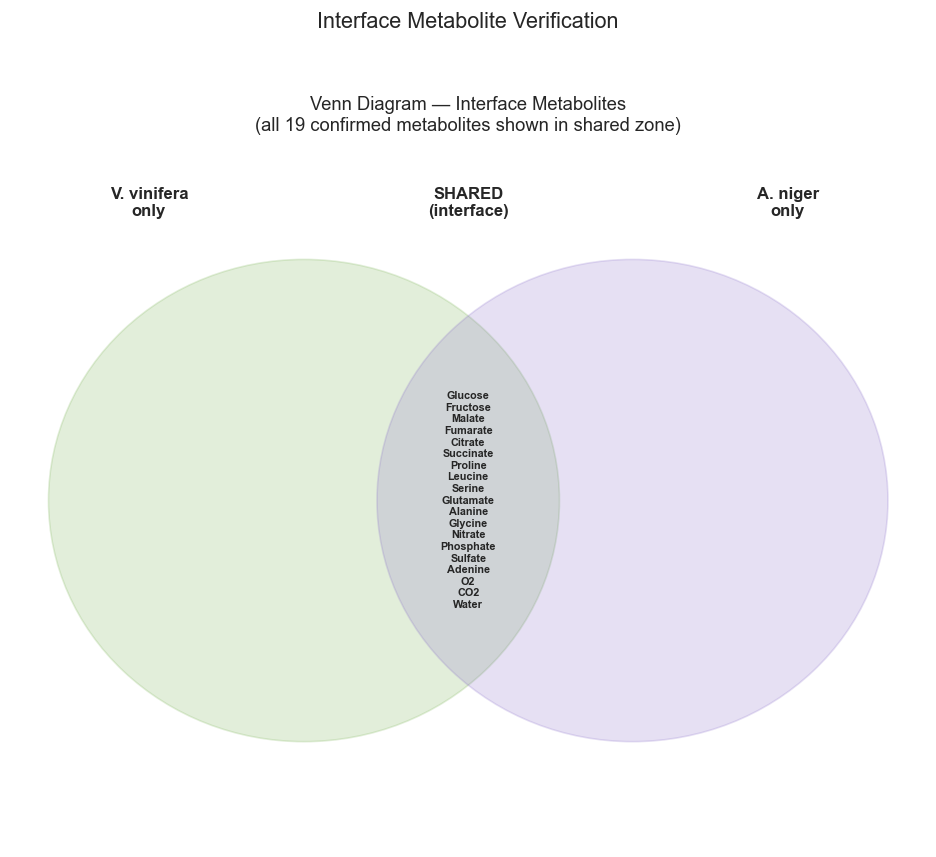

In BOTH: 19  |  VV only: 0  |  AN only: 0


In [7]:
# Venn diagram
fig, ax = plt.subplots(1, 1, figsize = (8, 7))

met_names  = list(interface_verified.keys())
both       = [m for m in met_names if interface_verified[m]['in_vv'] and interface_verified[m]['in_an']]
vv_only    = [m for m in met_names if interface_verified[m]['in_vv'] and not interface_verified[m]['in_an']]
an_only    = [m for m in met_names if not interface_verified[m]['in_vv'] and interface_verified[m]['in_an']]

ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')

ax.add_patch(plt.Circle((3.2, 4), 2.8, color = C_GRAPE,  alpha = 0.2))
ax.add_patch(plt.Circle((6.8, 4), 2.8, color = C_FUNGUS, alpha = 0.2))

ax.text(1.5, 4.0, '\n'.join(vv_only[:5]) or '',   ha = 'center', va = 'center', fontsize = 8,   fontweight = 'bold')
ax.text(8.5, 4.0, '\n'.join(an_only[:5]) or '',   ha = 'center', va = 'center', fontsize = 8,   fontweight = 'bold')
ax.text(5.0, 4.0, '\n'.join(both),                ha = 'center', va = 'center', fontsize = 6.5, fontweight = 'bold')

ax.text(1.5, 7.3, 'V. vinifera\nonly',   ha = 'center', fontsize = 10, fontweight = 'bold')
ax.text(8.5, 7.3, 'A. niger\nonly',      ha = 'center', fontsize = 10, fontweight ='bold')
ax.text(5.0, 7.3, 'SHARED\n(interface)', ha = 'center', fontsize = 10, fontweight = 'bold')

ax.set_title(f'Venn Diagram — Interface Metabolites\n(all {len(both)} confirmed metabolites shown in shared zone)', fontsize = 11, pad = 15)
plt.suptitle('Interface Metabolite Verification', fontsize = 13, y = 1.02)

plt.tight_layout()
# plt.savefig('fig1_venn_interface_fixed.png', dpi = 150, bbox_inches = 'tight')
plt.show()

print(f'In BOTH: {len(both)}  |  VV only: {len(vv_only)}  |  AN only: {len(an_only)}')

## 3. Model Renaming — Add Organism Prefixes

All reaction/metabolite/gene IDs receive `vv_` or `an_` prefixes to prevent ID collisions in the community model. FBA objective values must be identical before and after renaming.

In [8]:
def prefix_model(model_original, prefix):
    """Deep copy with all reaction/metabolite/gene IDs prepended with prefix_."""
    m = model_original.copy()
    m.id = prefix
    for met in m.metabolites:
        met.id = f'{prefix}_{met.id}'
        if met.compartment:
            met.compartment = f'{prefix}_{met.compartment}'
    m.compartments = {f'{prefix}_{k}': v for k, v in m.compartments.items()}
    for rxn in m.reactions:
        rxn.id = f'{prefix}_{rxn.id}'
    for gene in m.genes:
        gene.id = f'{prefix}_{gene.id}'
    return m

vv = prefix_model(vv_raw, 'vv')
an = prefix_model(an_raw, 'an')

mu_vv = vv.optimize().objective_value
mu_an = an.optimize().objective_value
assert abs(mu_vv - vv_sol_base.objective_value) < 1e-4, 'Grape μ changed after renaming!'
assert abs(mu_an - an_sol_base.objective_value) < 1e-4, 'Fungus μ changed after renaming!'
print(f'Grape  (prefixed) μ = {mu_vv:.4f} h⁻¹')
print(f'Fungus (prefixed) μ = {mu_an:.4f} h⁻¹')

# Key reaction IDs (with prefix)
vv_biomass_id = [r.id for r in vv.reactions
                 if 'biomass' in r.id.lower() and 'drain' not in r.id.lower()][0]
print(f'Grape biomass : {vv_biomass_id}')

an_growth_id = [r.id for r in an.reactions if r.objective_coefficient != 0][0]
print(f'Fungus objective: {an_growth_id}') 

Read LP format model from file /var/folders/zr/ls8263wn1l7b0wb53pbrcv9r0000gn/T/tmp_leh6qsb.lp
Reading time = 0.01 seconds
: 5143 rows, 8544 columns, 35884 nonzeros
Read LP format model from file /var/folders/zr/ls8263wn1l7b0wb53pbrcv9r0000gn/T/tmp4gani2ge.lp
Reading time = 0.00 seconds
: 1818 rows, 4640 columns, 16506 nonzeros
Grape  (prefixed) μ = 0.1541 h⁻¹
Fungus (prefixed) μ = 0.9399 h⁻¹
Grape biomass : vv_e-Biomass_vvinif2023_berry_mature__cyto
Fungus objective: an_DRAIN_Biomass


## 4. Community Model Construction

- **T1** (`vv_cytosol → inf`): lower bound = $0$, upper bound = proportional — strictly unidirectional;
- **T2** (`inf → an_extracellular`): lower bound = $0$, upper bound = $1000$ — strictly unidirectional;
- All `an_BOUNDARY_*` direct uptakes blocked — fungus imports ONLY via T2.

**Note on Fructose:** T1_Fructose and T2_Fructose are created with correct stoichiometry (`vv_Fructofuranose__cyto` → inf_Fructose → `an_FRUe`) but FVA confirms zero flux in both directions (*iJB1325* lacks efficient fructose catabolism). Fructose is retained in the interface for biological completeness — it IS abundant in the berry — but contributes zero to fungal growth in this model.

In [9]:
community = Model('community_VvM_An')
community.solver = 'gurobi'

for rxn in vv.reactions:
    community.add_reactions([rxn.copy()])
for rxn in an.reactions:
    community.add_reactions([rxn.copy()])

community.compartments['inf'] = 'infection_interface'
print(f'Community (pre-interface): {len(community.reactions)} rxns, {len(community.metabolites)} mets')

# Build INTERFACE_MAP using verified exact IDs
INTERFACE_MAP = {}
for name, v in interface_verified.items():
    if not v['include_T1'] or not v['include_T2']:
        print(f'    SKIP {name}: T1 = {v["include_T1"]}, T2 = {v["include_T2"]}')
        continue
    INTERFACE_MAP[name] = {'vv_cyto' : f'vv_{v["vv_cyto_id"]}',
                           'an_extr' : f'an_{v["an_extr_id"]}',
                           'category': v['category'],}

print(f'\nActive interface pairs: {len(INTERFACE_MAP)}')
for name, m in INTERFACE_MAP.items():
    arrow = '→'
    print(f'  {name:<12}: {m["vv_cyto"]:<25} → inf_{name:<12} {arrow} {m["an_extr"]}')

Community (pre-interface): 6592 rxns, 5967 mets

Active interface pairs: 19
  Glucose     : vv_GLC__cyto              → inf_Glucose      → an_GLCe
  Fructose    : vv_Fructofuranose__cyto   → inf_Fructose     → an_FRUe
  Malate      : vv_MAL__cyto              → inf_Malate       → an_MALe
  Fumarate    : vv_FUM__cyto              → inf_Fumarate     → an_FUMe
  Citrate     : vv_CIT__cyto              → inf_Citrate      → an_CITe
  Succinate   : vv_SUC__cyto              → inf_Succinate    → an_SUCCe
  Proline     : vv_PRO__cyto              → inf_Proline      → an_PROe
  Leucine     : vv_LEU__cyto              → inf_Leucine      → an_LEUe
  Serine      : vv_SER__cyto              → inf_Serine       → an_SERe
  Glutamate   : vv_GLT__cyto              → inf_Glutamate    → an_GLUe
  Alanine     : vv_L-ALPHA-ALANINE__cyto  → inf_Alanine      → an_ALAe
  Glycine     : vv_GLY__cyto              → inf_Glycine      → an_GLYe
  Nitrate     : vv_NITRATE__cyto          → inf_Nitrate      → an_HNO3e

In [10]:
print(f'Orphaned metabolites (not in any reaction): {6961 - len(community.metabolites)}')
vv_orphaned = [m for m in vv.metabolites if not m.reactions]
an_orphaned = [m for m in an.metabolites if not m.reactions]
print(f'Orphaned in vv : {len(vv_orphaned)}')
print(f'Orphaned in an : {len(an_orphaned)}')
print(f'Total          : {len(vv_orphaned) + len(an_orphaned)}')

Orphaned metabolites (not in any reaction): 994
Orphaned in vv : 962
Orphaned in an : 32
Total          : 994


In [11]:
T1_reactions = []
T2_reactions = []

for name, m in INTERFACE_MAP.items():
    # Create infection compartment metabolite
    inf_id = f'inf_{name}'
    if inf_id not in {x.id for x in community.metabolites}:
        inf_met = Metabolite(inf_id, name = f'{name} (infection)', compartment = 'inf')
        try:
            src = community.metabolites.get_by_id(m['an_extr'])
            inf_met.formula = src.formula
            inf_met.charge  = 0
        except KeyError:
            pass
    else:
        inf_met = community.metabolites.get_by_id(inf_id)

    # T1: grape cytosol → infection (UNIDIRECTIONAL)
    t1 = Reaction(f'T1_{name}',
                  name         = f'T1: V.vinifera cytosol → infection ({name})',
                  lower_bound  = 0, 
                  upper_bound  = 1000,
                  subsystem    = 'T1_transport')
    try:
        vv_met = community.metabolites.get_by_id(m['vv_cyto'])
        t1.add_metabolites({vv_met: -1, inf_met: 1})
        community.add_reactions([t1])
        T1_reactions.append(f'T1_{name}')
    except KeyError as e:
        print(f'T1 SKIP {name}: {e}'); continue

    # T2: infection → fungus extracellular (UNIDIRECTIONAL)
    t2 = Reaction(f'T2_{name}',
                  name        = f'T2: infection → A.niger extracellular ({name})',
                  lower_bound = 0, 
                  upper_bound = 1000,
                  subsystem   = 'T2_transport')
    try:
        an_met = community.metabolites.get_by_id(m['an_extr'])
        t2.add_metabolites({inf_met: -1, an_met: 1})
        community.add_reactions([t2])
        T2_reactions.append(f'T2_{name}')
    except KeyError as e:
        print(f'T2 SKIP {name}: {e}')

print(f'T1 reactions : {len(T1_reactions)}')
print(f'T2 reactions : {len(T2_reactions)}')
print(f'Community    : {len(community.reactions)} rxns, {len(community.metabolites)} mets')

T1 reactions : 19
T2 reactions : 19
Community    : 6630 rxns, 5986 mets


In [12]:
# Verify no T1 uses chloroplast metabolites
chloro_in_T1 = []
for t1_id in T1_reactions:
    rxn = community.reactions.get_by_id(t1_id)
    for met in rxn.reactants:
        if 'chloro' in met.compartment:
            chloro_in_T1.append((t1_id, met.id))
            rxn.upper_bound = 0

if chloro_in_T1:
    print(f'{len(chloro_in_T1)} T1 reactions used chloroplast mets')
    for r, m in chloro_in_T1: print(f'  {r} → {m}')
else:
    print('No T1 reactions use chloroplast metabolites.')

# 2. Block all direct fungus nutrient uptakes (fungus must use ONLY what arrives via T2)
blocked_an   = 0
blocked_list = []

for rxn in community.reactions:
    if rxn.id.startswith('an_BOUNDARY_'):
        if rxn.lower_bound < 0:
            rxn.lower_bound = 0
            blocked_an += 1
            blocked_list.append(rxn.id)

print(f'Blocked direct uptake of {blocked_an} fungus boundary reactions:')
for r in blocked_list:
    print(f'    {r}')

No T1 reactions use chloroplast metabolites.
Blocked direct uptake of 8 fungus boundary reactions:
    an_BOUNDARY_GLCe
    an_BOUNDARY_H2Oe
    an_BOUNDARY_HNO3e
    an_BOUNDARY_O2e
    an_BOUNDARY_PIe
    an_BOUNDARY_SLFe
    an_BOUNDARY_Ke
    an_BOUNDARY_CAe


## 5. Baseline Verification

Three checks confirm the architecture:
1. Grape is feasible in community
2. Fungus growth = $0$ when T2 blocked (no nutrients)
3. Fungus grows when T2 fully open

In [13]:
rxn_vv = community.reactions.get_by_id(vv_biomass_id)
rxn_an = community.reactions.get_by_id(an_growth_id)

# 1. Grape baseline
with community:
    community.objective = {rxn_vv: 1}
    sol = community.optimize()
    print(f'1. Grape in community       : μ = {sol.objective_value:.4f} h⁻¹')
    print(f'   Grape isolated (Phase 1B): μ = {vv_sol_base.objective_value:.4f} h⁻¹')

# 2. Fungus with T2 blocked
with community:
    for t2_id in T2_reactions:
        try: r = community.reactions.get_by_id(t2_id); r.upper_bound = 0; r.lower_bound = 0
        except KeyError: pass
    community.objective = {rxn_an: 1}
    sol = community.optimize()
    g = sol.objective_value if sol.status == 'optimal' else 0
    ok = 'correct' if g < 0.01 else 'FUNGUS STILL GROWS'
    print(f'\n2. Fungus (T2 blocked)     : μ = {g:.4f} h⁻¹  {ok}')

# 3. Fungus with T1+T2 fully open
with community:
    for t_id in T1_reactions + T2_reactions:
        try: community.reactions.get_by_id(t_id).upper_bound = 10.0
        except KeyError: pass
    community.objective = {rxn_an: 1}
    sol = community.optimize()
    baseline_an = sol.objective_value if sol.status == 'optimal' else 0
    print(f'\n3. Fungus (T1/T2 open)     : μ = {baseline_an:.4f} h⁻¹')

1. Grape in community       : μ = 0.1541 h⁻¹
   Grape isolated (Phase 1B): μ = 0.1541 h⁻¹

2. Fungus (T2 blocked)     : μ = 0.0000 h⁻¹  correct

3. Fungus (T1/T2 open)     : μ = 0.1809 h⁻¹


## 6. Simulation Architecture — Leakage Model

**Design:** No external concentration data is imposed. The trade-off between grape self-maintenance and nutrient export emerges from the grape's own metabolic state.

**Biological rationale:** As *A. niger* hyphae penetrate cell walls, cytoplasmic metabolites leak into the infection interface at a rate proportional to:
1. The intensity of infection (`f_infection`);
2. The metabolic activity of the grape for that metabolite (cytoplasmic flux proxy).

**Leakage model — variables and units:**

`f_infection = bm_an / (bm_an + half_sat)`

* `bm_an` — *A. niger* biomass concentration (g DW/L);
* `half_sat` — half-saturation constant (g DW/L): the fungal biomass at which f_infection = 0.5;
* `f_infection` — dimensionless [0, 1]: fraction of berry cytoplasm exposed to the infection interface at a given moment.

---

`T1_ub[met] = f_infection × cyto_flux_proxy[met]`

* `T1_ub[met]` — upper bound of the T1 transport reaction for metabolite *met* (mmol/gDW/h): maximum rate at which *met* can leak from berry cytosol into the infection compartment
* `cyto_flux_proxy[met]` — cytoplasmic metabolic activity of the berry for *met* (mmol/gDW/h): scales the leakage potential

---

`cyto_flux_proxy[met] = Σ |flux| of grape reactions consuming met in cytosol`

* `cyto_flux_proxy[met]`- sum of absolute fluxes of all cytosolic reactions that consume *met*, evaluated from grape pFBA at full metabolic capacity (mmol/gDW/h) - represents how actively the berry "turns over" each metabolite — high turnover → high leakage potential when the cell wall is breached (computed once per stage (green or mature) and held constant throughout the dFBA simulation)

---

**Properties:**
- `f_infection = 0` → T1 = 0 (no hyphae, no leakage)
- `f_infection = 1` → T1 = full cytoplasmic metabolic activity
- Grape pFBA minimises T1 where possible — the grape resists passively

**Key result:**
Citrate ($19.37$) and Phosphate ($13.33$) dominate due to high TCA/phosphorylation flux. Glucose ($0.90$) and Fructose ($1.03$) are present via anomeric forms (`ALPHA-GLUCOSE__cyto`, `BETA-D-FRUCTOSE__cyto`) — cytoplasmic invertase products.

In [14]:
GAS_NAMES = {'O2', 'CO2', 'Water'}

INTERFACE_CYTO_IDS = {name: [ids['vv_id']] for name, ids in INTERFACE_EXACT.items()}
INTERFACE_CYTO_IDS['Glucose']  = ['GLC__cyto', 'ALPHA-GLUCOSE__cyto']
INTERFACE_CYTO_IDS['Fructose'] = ['Fructofuranose__cyto', 'BETA-D-FRUCTOSE__cyto']

def compute_proxy(community, vv_biomass_id):
    """Compute cyto_flux_proxy from grape pFBA at full capacity."""
    prefix = vv_biomass_id.split('_')[0]
    with community:
        community.objective = {community.reactions.get_by_id(vv_biomass_id): 1}
        sol_full = pfba(community)

    proxy = {}
    for name in INTERFACE_MAP:
        total = 0.0
        for base_id in INTERFACE_CYTO_IDS[name]:
            vv_cyto_id = f'{prefix}_{base_id}'
            try:
                met = community.metabolites.get_by_id(vv_cyto_id)
                total += sum(
                    abs(sol_full.fluxes.get(rxn.id, 0))
                    for rxn in met.reactions
                    if rxn.metabolites.get(met, 0) < 0
                    and rxn.id.startswith(f'{prefix}_')
                )
            except KeyError:
                pass
        proxy[name] = total
    return proxy

cyto_flux_proxy = compute_proxy(community, vv_biomass_id)

print(f'GAS_NAMES : {GAS_NAMES}')
print()
print('Cytoplasmic flux proxies (grape pFBA, full capacity):')
for name, val in sorted(cyto_flux_proxy.items(), key=lambda x: x[1], reverse=True):
    if name not in GAS_NAMES:
        bar = '\u2588' * min(30, int(val * 1.5))
        print(f'  {name:<14}: {val:>8.4f} mmol/gDW/h  {bar}')

GAS_NAMES : {'Water', 'CO2', 'O2'}

Cytoplasmic flux proxies (grape pFBA, full capacity):
  Citrate       :  19.3676 mmol/gDW/h  █████████████████████████████
  Phosphate     :  13.2741 mmol/gDW/h  ███████████████████
  Glycine       :   2.5920 mmol/gDW/h  ███
  Alanine       :   1.9469 mmol/gDW/h  ██
  Glutamate     :   1.5387 mmol/gDW/h  ██
  Nitrate       :   1.4644 mmol/gDW/h  ██
  Serine        :   1.2802 mmol/gDW/h  █
  Fructose      :   1.0310 mmol/gDW/h  █
  Glucose       :   0.8989 mmol/gDW/h  █
  Malate        :   0.1876 mmol/gDW/h  
  Leucine       :   0.1460 mmol/gDW/h  
  Fumarate      :   0.0754 mmol/gDW/h  
  Succinate     :   0.0462 mmol/gDW/h  
  Proline       :   0.0347 mmol/gDW/h  
  Sulfate       :   0.0161 mmol/gDW/h  
  Adenine       :   0.0115 mmol/gDW/h  


## 7. Infection Intensity Scan — Host Suppression and Fungal Growth

Steady-state scan of infection intensity (`f_infection` $0.0 → 1.0$, 
step $0.05$). At each step, T1 bounds are set from the leakage formula 
and both FBAs are solved independently.

**Result:** Smooth, continuous parasitism gradient — no binary switching. Fungal growth saturates at ~`f_infection` = $0.55$ when T1 provides sufficient nutrients; host growth declines proportionally throughout.

In [15]:
vv_mu_max = vv_sol_base.objective_value
f_infection_values = np.arange(0.0, 1.01, 0.05)
inf_results = []

print(f'Grape μ_max: {vv_mu_max:.4f} h⁻¹')
print(f'Infection scan: {len(f_infection_values)} points (f_infection 0.0 → 1.0)\n')

for f_infection in f_infection_values:
    f_infection = round(float(f_infection), 2)
    f_host      = max(0.0, 1.0 - f_infection)

    T1_actual = {f'T1_{name}': max(0.0, cyto_flux_proxy.get(name, 0) * f_infection)
                 for name in INTERFACE_MAP if name not in GAS_NAMES}

    with community:
        community.reactions.get_by_id(vv_biomass_id).upper_bound = max(0.0, f_host * vv_mu_max)
        community.objective = {community.reactions.get_by_id(vv_biomass_id): 1}
        sol_vv    = community.optimize()
        vv_growth = sol_vv.objective_value if sol_vv.status == 'optimal' else 0

    with community:
        for t1_id, flux in T1_actual.items():
            t2_id = t1_id.replace('T1_', 'T2_')
            try:
                t2r = community.reactions.get_by_id(t2_id)
                if t2r.lower_bound >= 0:
                    t2r.upper_bound = max(0.0, flux)
            except KeyError: pass
        community.objective = {community.reactions.get_by_id(an_growth_id): 1}
        sol_an    = community.optimize()
        an_growth = sol_an.objective_value if sol_an.status == 'optimal' else 0

    t1_tot = sum(T1_actual.values())
    inf_results.append({'f_inf'    : round(f_infection, 2),
                        'f_host'   : round(f_host, 4),
                        'vv_mu'    : round(vv_growth, 4),
                        'an_mu'    : round(an_growth, 4),
                        'T1_total' : round(t1_tot, 4),
                        'status'   : 'ok',})
    print(f'    f_inf = {f_infection:.2f} vv = {vv_growth:.4f} an = {an_growth:.4f} T1 = {t1_tot:.3f}')

df_inf = pd.DataFrame(inf_results)

Grape μ_max: 0.1541 h⁻¹
Infection scan: 21 points (f_infection 0.0 → 1.0)

    f_inf = 0.00 vv = 0.1541 an = 0.0000 T1 = 0.000
    f_inf = 0.05 vv = 0.1464 an = 0.0166 T1 = 2.196
    f_inf = 0.10 vv = 0.1387 an = 0.0332 T1 = 4.391
    f_inf = 0.15 vv = 0.1310 an = 0.0498 T1 = 6.587
    f_inf = 0.20 vv = 0.1233 an = 0.0664 T1 = 8.782
    f_inf = 0.25 vv = 0.1156 an = 0.0830 T1 = 10.978
    f_inf = 0.30 vv = 0.1079 an = 0.0997 T1 = 13.173
    f_inf = 0.35 vv = 0.1002 an = 0.1163 T1 = 15.369
    f_inf = 0.40 vv = 0.0925 an = 0.1329 T1 = 17.565
    f_inf = 0.45 vv = 0.0848 an = 0.1495 T1 = 19.760
    f_inf = 0.50 vv = 0.0771 an = 0.1661 T1 = 21.956
    f_inf = 0.55 vv = 0.0694 an = 0.1749 T1 = 24.151
    f_inf = 0.60 vv = 0.0616 an = 0.1753 T1 = 26.347
    f_inf = 0.65 vv = 0.0539 an = 0.1757 T1 = 28.542
    f_inf = 0.70 vv = 0.0462 an = 0.1760 T1 = 30.738
    f_inf = 0.75 vv = 0.0385 an = 0.1763 T1 = 32.934
    f_inf = 0.80 vv = 0.0308 an = 0.1767 T1 = 35.129
    f_inf = 0.85 vv = 0.0231 

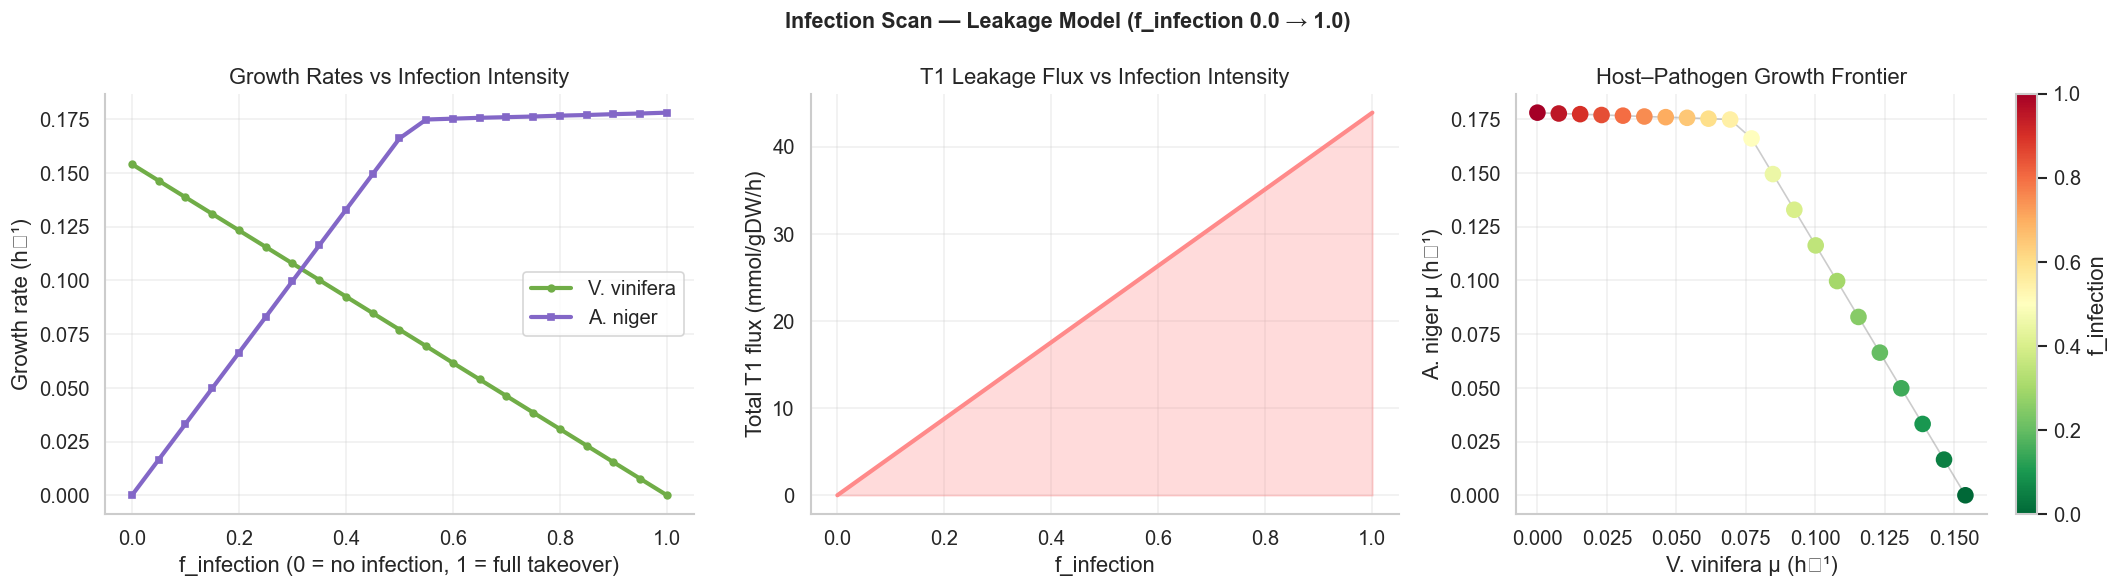

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Infection Scan — Leakage Model (f_infection 0.0 → 1.0)', fontsize = 13, fontweight = 'bold')

ok = df_inf[df_inf['status'] == 'ok']

axes[0].plot(ok['f_inf'], ok['vv_mu'], color = C_GRAPE,  lw = 2.5, marker = 'o', ms = 4, label = 'V. vinifera')
axes[0].plot(ok['f_inf'], ok['an_mu'], color = C_FUNGUS, lw = 2.5, marker = 's', ms = 4, label = 'A. niger')
axes[0].set_xlabel('f_infection (0 = no infection, 1 = full takeover)')
axes[0].set_ylabel('Growth rate (h⁻¹)')
axes[0].set_title('Growth Rates vs Infection Intensity')
axes[0].legend(); axes[0].grid(alpha = 0.3)

axes[1].fill_between(ok['f_inf'], ok['T1_total'], alpha = 0.3, color = C_INF)
axes[1].plot(ok['f_inf'], ok['T1_total'], color = C_INF, lw = 2.5)
axes[1].set_xlabel('f_infection')
axes[1].set_ylabel('Total T1 flux (mmol/gDW/h)')
axes[1].set_title('T1 Leakage Flux vs Infection Intensity')
axes[1].grid(alpha = 0.3)

sc = axes[2].scatter(ok['vv_mu'], ok['an_mu'], c = ok['f_inf'], cmap = 'RdYlGn_r', s = 80, zorder = 3)
axes[2].plot(ok['vv_mu'], ok['an_mu'], color = 'grey', lw = 1, alpha = 0.4)
plt.colorbar(sc, ax=axes[2], label='f_infection')
axes[2].set_xlabel('V. vinifera μ (h⁻¹)')
axes[2].set_ylabel('A. niger μ (h⁻¹)')
axes[2].set_title('Host–Pathogen Growth Frontier')
axes[2].grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('fig2_infection_scan.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. dFBA — Infection Progression

**Architecture:** Leakage model — T1 bounds from grape pFBA metabolic activity.

---

`f_host = 1 − f_infection`

* `f_host` — dimensionless [0, 1]: fraction of berry metabolic capacity remaining under host control; used to constrain the grape FBA upper bound at each timestep: vv_biomass.upper_bound = f_host × μ_max

**Properties:**
- `f_host = 0` → (full takeover): grape growth is completely suppressed
- `f_host = 1` → (no infection): grape operates at full capacity

---

**Key design decisions:**
- `bm_vv` is **CONSTANT** — mature berry is post-mitotic
- T1 bounds from grape's own metabolic activity — no external concentration data
- `f_infection` driven by fungal biomass accumulation
- Vine supply modelled via `vv_BOUNDARY_*` reactions — no hardcoded replenishment rates
- Two decoupled FBAs per timestep: grape FBA → vv_growth; fungus FBA → an_growth

**Results (dt = 1.0h, t_end = 120h):**
* *A. niger* reaches carrying capacity ($K = 50 gDW/L$) at $t ≈ 85h$.
* `f_infection` reaches $0.9998$ by $t = 120h$ — near-complete metabolic takeover.
* Citrate (~$18 mmol/gDW/h$) and Phosphate (~$13 mmol/gDW/h$) dominate T1 leakage

**Note:** `bm_vv` remains constant at 1.0 gDW/L throughout the simulation — the berry does not lose biomass. The decline of `vv_μ → 0` represents progressive metabolic suppression as `f_host` → $0$, not physical tissue death. Actual berry degradation (cell wall lysis by fungal pectinases and cellulases) is not captured at the constraint-based level.

In [17]:
def run_dfba(community,
             vv_biomass_id,
             an_growth_id,
             T1_reactions,
             T2_reactions,
             INTERFACE_MAP,
             cyto_flux_proxy,
             biomass_vv_0 = 1.0,
             biomass_an_0 = 0.001,
             dt           = 0.5,
             t_end        = 120.0,
             K_fungus     = 50.0,
             half_sat     = 0.01,
             f_host_fixed = None,
             label        = ''):
    """
    dFBA — Leakage Model.
    """
    rxn_vv     = community.reactions.get_by_id(vv_biomass_id)
    rxn_an     = community.reactions.get_by_id(an_growth_id)
    bm_vv      = biomass_vv_0
    bm_an      = biomass_an_0
    results    = []

    with community:
        community.objective = {rxn_vv: 1}
        _vv_mu_max = community.optimize().objective_value
    
    rxn_vv.lower_bound = 0.0; rxn_vv.upper_bound = 1000.0
    rxn_an.lower_bound = 0.0; rxn_an.upper_bound = 1000.0

    try:
        for t in np.arange(0, t_end, dt):

            if f_host_fixed is not None:
                f_host      = f_host_fixed
                f_infection = 1.0 - f_host
            else:
                f_infection = bm_an / (bm_an + half_sat)
                f_host      = 1.0 - f_infection

            T1_actual = {f'T1_{name}': max(0.0, cyto_flux_proxy.get(name, 0) * f_infection)
                         for name in INTERFACE_MAP if name not in GAS_NAMES}

            with community:
                rxn_vv.upper_bound = max(0.0, f_host * _vv_mu_max)
                community.objective = {rxn_vv: 1}
                sol_vv    = community.optimize()
                vv_growth = sol_vv.objective_value if sol_vv.status == 'optimal' else 0

            with community:
                for t1_id, flux in T1_actual.items():
                    t2_id = t1_id.replace('T1_', 'T2_')
                    try:
                        t2r = community.reactions.get_by_id(t2_id)
                        if t2r.lower_bound >= 0:
                            t2r.upper_bound = max(0.0, flux)
                    except KeyError: pass
                community.objective = {rxn_an: 1}
                sol_an    = community.optimize()
                an_growth = sol_an.objective_value if sol_an.status == 'optimal' else 0

            bm_an = min(bm_an + an_growth * bm_an * dt, K_fungus)

            row = {'time_h'     : round(t, 2),
                   'biomass_vv' : round(bm_vv, 5),
                   'biomass_an' : round(bm_an, 5),
                   'f_host'     : round(f_host, 4),
                   'f_infection': round(f_infection, 4),
                   'vv_growth'  : round(vv_growth, 5),
                   'an_growth'  : round(an_growth, 5),
                   'T1_total'   : round(sum(T1_actual.values()), 4),}
            for t1_id in T1_reactions:
                row[f'flux_{t1_id}'] = round(T1_actual.get(t1_id, 0), 5)
            results.append(row)

    finally:
        rxn_vv.lower_bound = 0.0; rxn_vv.upper_bound = 1000.0
        rxn_an.lower_bound = 0.0; rxn_an.upper_bound = 1000.0

    return pd.DataFrame(results)

In [18]:
df_dfba = run_dfba(community,
                   vv_biomass_id,
                   an_growth_id,
                   T1_reactions,
                   T2_reactions,
                   INTERFACE_MAP,
                   cyto_flux_proxy,
                   dt    = 0.5,
                   t_end = 120.0,
                   label = '[base]')

if len(df_dfba) > 0:
    peak_an = df_dfba['biomass_an'].max()
    t_peak  = df_dfba.loc[df_dfba['biomass_an'].idxmax(), 'time_h']
    print(f'Simulation    : {len(df_dfba)} timesteps')
    print(f'Peak A. niger : {peak_an:.3f} gDW/L at t = {t_peak:.0f}h')
    print(f'f_infection   : {df_dfba["f_infection"].iloc[-1]:.4f}')
else:
    print('Empty DataFrame.')

Simulation    : 240 timesteps
Peak A. niger : 50.000 gDW/L at t = 85h
f_infection   : 0.9998


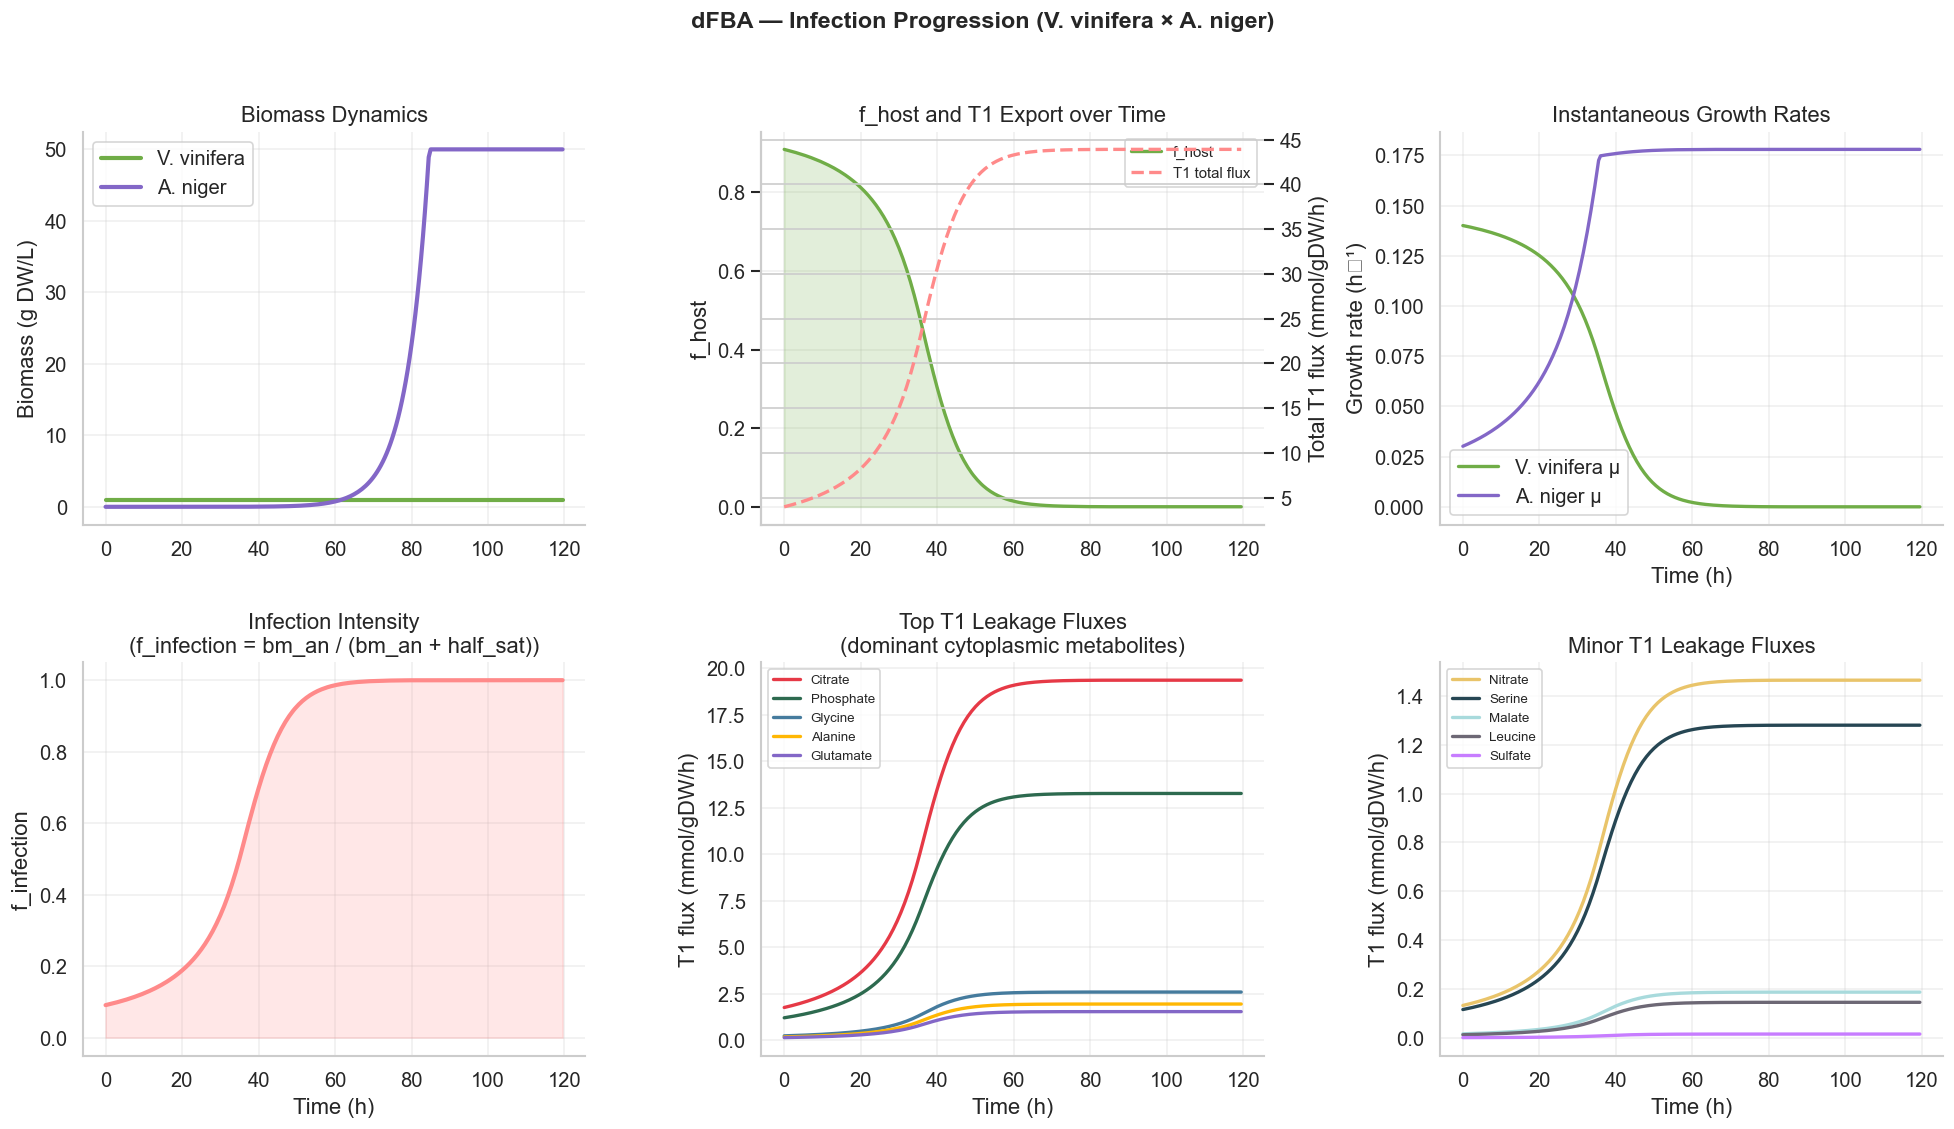

In [19]:
fig = plt.figure(figsize = (20, 10))
fig.suptitle('dFBA — Infection Progression (V. vinifera × A. niger)', fontsize = 14, fontweight = 'bold')

gs   = fig.add_gridspec(2, 3, hspace = 0.35, wspace = 0.35)
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax02 = fig.add_subplot(gs[0, 2])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])
ax12 = fig.add_subplot(gs[1, 2])

# [0,0] Biomass Dynamics
ax00.plot(df_dfba['time_h'], df_dfba['biomass_vv'], color = C_GRAPE,  lw = 2.5, label = 'V. vinifera')
ax00.plot(df_dfba['time_h'], df_dfba['biomass_an'], color = C_FUNGUS, lw = 2.5, label = 'A. niger')
ax00.set_ylabel('Biomass (g DW/L)'); ax00.set_title('Biomass Dynamics')
ax00.legend(); ax00.grid(alpha = 0.3)

# [0,1] f_host + T1 total flux
ax01b = ax01.twinx()
ax01.fill_between(df_dfba['time_h'], df_dfba['f_host'], alpha = 0.2, color = C_GRAPE)
ax01.plot(df_dfba['time_h'], df_dfba['f_host'],    color = C_GRAPE, lw = 2,   label = 'f_host')
ax01b.plot(df_dfba['time_h'], df_dfba['T1_total'], color = C_INF,   lw = 2, ls = '--', label = 'T1 total flux')
ax01.set_ylabel('f_host'); ax01b.set_ylabel('Total T1 flux (mmol/gDW/h)')
ax01.set_title('f_host and T1 Export over Time')
l1,lb1 = ax01.get_legend_handles_labels(); l2,lb2 = ax01b.get_legend_handles_labels()
ax01.legend(l1+l2, lb1+lb2, fontsize = 9); ax01.grid(alpha = 0.3)

# [0,2] Instantaneous Growth Rates
ax02.plot(df_dfba['time_h'], df_dfba['vv_growth'], color = C_GRAPE,  lw = 2, label = 'V. vinifera μ')
ax02.plot(df_dfba['time_h'], df_dfba['an_growth'], color = C_FUNGUS, lw = 2, label = 'A. niger μ')
ax02.set_ylabel('Growth rate (h⁻¹)'); ax02.set_xlabel('Time (h)')
ax02.set_title('Instantaneous Growth Rates')
ax02.legend(); ax02.grid(alpha = 0.3)

# [1,0] f_infection
ax10.plot(df_dfba['time_h'], df_dfba['f_infection'], color = C_INF, lw = 2.5)
ax10.fill_between(df_dfba['time_h'], df_dfba['f_infection'], alpha = 0.2, color = C_INF)
ax10.set_ylabel('f_infection'); ax10.set_xlabel('Time (h)')
ax10.set_title('Infection Intensity\n(f_infection = bm_an / (bm_an + half_sat))')
ax10.grid(alpha = 0.3)

# [1,1] Top T1 fluxes — dominant leakage metabolites
top_mets = ['Citrate', 'Phosphate', 'Glycine', 'Alanine', 'Glutamate']
colors_t1 = ['#E63946', '#2D6A4F', '#457B9D', '#FFB703', '#8367C7']
for name, col in zip(top_mets, colors_t1):
    col_id = f'flux_T1_{name}'
    if col_id in df_dfba.columns:
        ax11.plot(df_dfba['time_h'], df_dfba[col_id], color = col, lw = 2, label = name)
ax11.set_ylabel('T1 flux (mmol/gDW/h)'); ax11.set_xlabel('Time (h)')
ax11.set_title('Top T1 Leakage Fluxes\n(dominant cytoplasmic metabolites)')
ax11.legend(fontsize = 8); ax11.grid(alpha = 0.3)

# [1,2] Minor T1 fluxes
minor_mets = ['Nitrate', 'Serine', 'Malate', 'Leucine', 'Sulfate']
colors_t1m = ['#E9C46A', '#264653', '#A8DADC', '#6D6875', '#C77DFF']
for name, col in zip(minor_mets, colors_t1m):
    col_id = f'flux_T1_{name}'
    if col_id in df_dfba.columns:
        ax12.plot(df_dfba['time_h'], df_dfba[col_id], color = col, lw = 2, label = name)
ax12.set_ylabel('T1 flux (mmol/gDW/h)'); ax12.set_xlabel('Time (h)')
ax12.set_title('Minor T1 Leakage Fluxes')
ax12.legend(fontsize = 8); ax12.grid(alpha = 0.3)

# plt.savefig('fig3_dfba_base.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## 9. Tipping Point Analysis — Metabolic Sustainability Frontier

Identifies the host growth rate at which sustaining both organisms becomes infeasible — the **metabolic tipping point** of infection. For each fixed host growth rate, the maximum achievable fungal growth is computed.

Instead of scanning T1 export parametrically, here the host biomass constraint is fixed and fungal growth is maximised directly. The tipping point is where forcing the host to maintain higher activity starves the fungus.

  Host μ (fixed)   Fungus μ (max)       Status
________________________________________________
          0.0000           0.1809      optimal
          0.0100           0.1709      optimal
          0.0300           0.1486      optimal
          0.0500           0.1252      optimal
          0.0700           0.1018      optimal
          0.0900           0.0783      optimal
          0.1100           0.0545      optimal
          0.1300           0.0304      optimal
          0.1400           0.0183      optimal
          0.1500           0.0062      optimal
          0.1540           0.0014      optimal ← TIPPING POINT


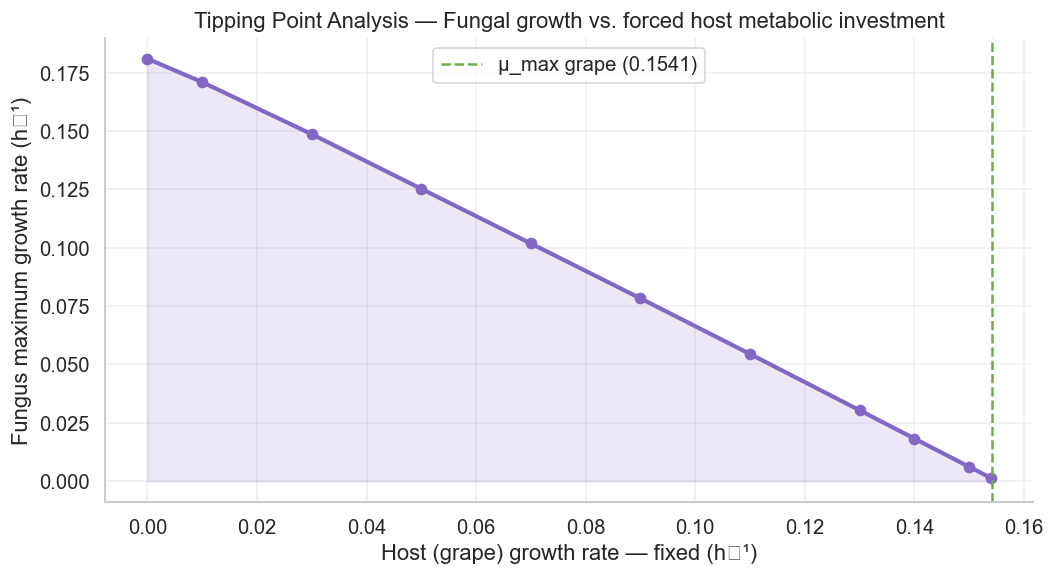

In [20]:
tipping_results = []
host_test_rates = [0.000, 0.010, 0.030, 0.050, 0.070, 0.090, 0.110, 0.130, 0.140, 0.150, 0.154]

print(f'{"Host μ (fixed)":>16} {"Fungus μ (max)":>16} {"Status":>12}')
print('_' * 48)

with community:
    for t_id in T1_reactions + T2_reactions:
        try: community.reactions.get_by_id(t_id).upper_bound = 10.0
        except KeyError: pass

    for host_rate in host_test_rates:
        with community:
            rxn_vv.lower_bound  = max(0.0, host_rate - 0.001)
            rxn_vv.upper_bound  = host_rate
            community.objective = {rxn_an: 1}
            sol = community.optimize()
            an_mu = sol.objective_value if sol.status == 'optimal' else 0.0
            tipping_results.append({'host_mu': host_rate, 'fungus_mu': round(an_mu, 4), 'status': sol.status})
            flag = ' ← TIPPING POINT' if host_rate > 0 and an_mu < 0.01 * vv_mu_max else ''
            print(f'{host_rate:>16.4f} {an_mu:>16.4f} {sol.status:>12}{flag}')

df_tipping = pd.DataFrame(tipping_results)

fig, ax = plt.subplots(figsize=(9, 5))
ok = df_tipping[df_tipping['status'] == 'optimal']
ax.plot(ok['host_mu'], ok['fungus_mu'], color = C_FUNGUS, lw = 2.5, marker = 'o', ms = 6)
ax.fill_between(ok['host_mu'], ok['fungus_mu'], alpha = 0.15, color = C_FUNGUS)
ax.axvline(x = vv_mu_max, color = C_GRAPE, lw = 1.5, ls = '--', label = f'μ_max grape ({vv_mu_max:.4f})')
ax.set_xlabel('Host (grape) growth rate — fixed (h⁻¹)')
ax.set_ylabel('Fungus maximum growth rate (h⁻¹)')
ax.set_title('Tipping Point Analysis — Fungal growth vs. forced host metabolic investment')
ax.legend(); ax.grid(alpha = 0.3)
plt.tight_layout()
# plt.savefig('fig4_tipping_point.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## 10. Differential Flux Analysis — Start vs End of Infection

FBA is run at two infection states:
- **Start** (`f_host = 0.50`): mid-infection — grape at 50% capacity, T1/T2 fully open to $10.0$ mmol/gDW/h ($μ = 0.1809 h⁻¹$)
- **End** (`f_host = 0.00`): full takeover — grape suppressed, T1/T2 fully open to $10.0$ mmol/gDW/h ($μ = 0.1809 h⁻¹$)

Δflux = flux_end − flux_start  
**SHIFTS** = reactions with |Δflux| > `SHIFT_THRESHOLD` = $0.1$ mmol/gDW/h

**Methodological note:**
Both states are run with all T1/T2 bounds open — growth rate is identical at both points ($Δμ = 0.0000 h⁻¹$). The differential flux analysis therefore captures **pure flux redistribution** between infection states, not growth-rate-driven changes. The fungus reorganises its internal metabolic flux distribution (glycolysis intensity, energy metabolism, redox balance) even when operating at the same growth rate — reflecting adaptation to the changing metabolite supply profile as host suppression increases. `SHIFT_THRESHOLD = 0.1` filters numerical noise and retains only biologically meaningful flux changes.

In [21]:
F_START = 0.50
F_END   = 0.00

with community:
    rxn_vv.upper_bound = max(0.0, F_START * vv_mu_max)
    for t1_id in T1_reactions:
        try: community.reactions.get_by_id(t1_id).upper_bound = 10.0
        except KeyError: pass
    for t2_id in T2_reactions:
        try: community.reactions.get_by_id(t2_id).upper_bound = 10.0
        except KeyError: pass
    community.objective = {rxn_an: 1}
    sol_start    = pfba(community)
    fluxes_start = sol_start.fluxes if sol_start.fluxes is not None else pd.Series(dtype = float)
    print(f'START (f_host = {F_START}): fungal growth = {fluxes_start.get(an_growth_id, 0):.4f} h⁻¹')

with community:
    rxn_vv.upper_bound = 0.0
    for t1_id in T1_reactions:
        try: community.reactions.get_by_id(t1_id).upper_bound = 10.0
        except KeyError: pass
    for t2_id in T2_reactions:
        try: community.reactions.get_by_id(t2_id).upper_bound = 10.0
        except KeyError: pass
    community.objective = {rxn_an: 1}
    sol_end    = pfba(community)
    fluxes_end = sol_end.fluxes if sol_end.fluxes is not None else pd.Series(dtype = float)
    print(f'END   (f_host = {F_END:.2f}): fungal growth = {fluxes_end.get(an_growth_id, 0):.4f} h⁻¹')

START (f_host = 0.5): fungal growth = 0.1809 h⁻¹
END   (f_host = 0.00): fungal growth = 0.1809 h⁻¹


In [22]:
all_rxns = set(fluxes_start.index) | set(fluxes_end.index)
df_dfa = pd.DataFrame({'flux_start': fluxes_start.reindex(all_rxns, fill_value = 0),
                       'flux_end'  : fluxes_end.reindex(all_rxns,   fill_value = 0),})
df_dfa['delta']     = df_dfa['flux_end'] - df_dfa['flux_start']
df_dfa['abs_delta'] = df_dfa['delta'].abs()
df_dfa['organism']  = df_dfa.index.map(
    lambda r: 'vv' if r.startswith('vv_') else
              'an' if r.startswith('an_') else
              'interface' if r.startswith('T') else 'other')

SHIFT_THRESHOLD = 0.1

df_shifts = df_dfa[df_dfa['abs_delta'] > SHIFT_THRESHOLD].sort_values('abs_delta', ascending = False)

print(f'SHIFTS (|Δflux| > {SHIFT_THRESHOLD:.3f}): {len(df_shifts)} reactions')
print(f'  A. niger    : {(df_shifts["organism"] == "an").sum()}')
print(f'  V. vinifera : {(df_shifts["organism"] == "vv").sum()}')
print(f'  Interface.  : {(df_shifts["organism"] == "interface").sum()}')

SHIFTS (|Δflux| > 0.100): 20 reactions
  A. niger    : 16
  V. vinifera : 4
  Interface.  : 0


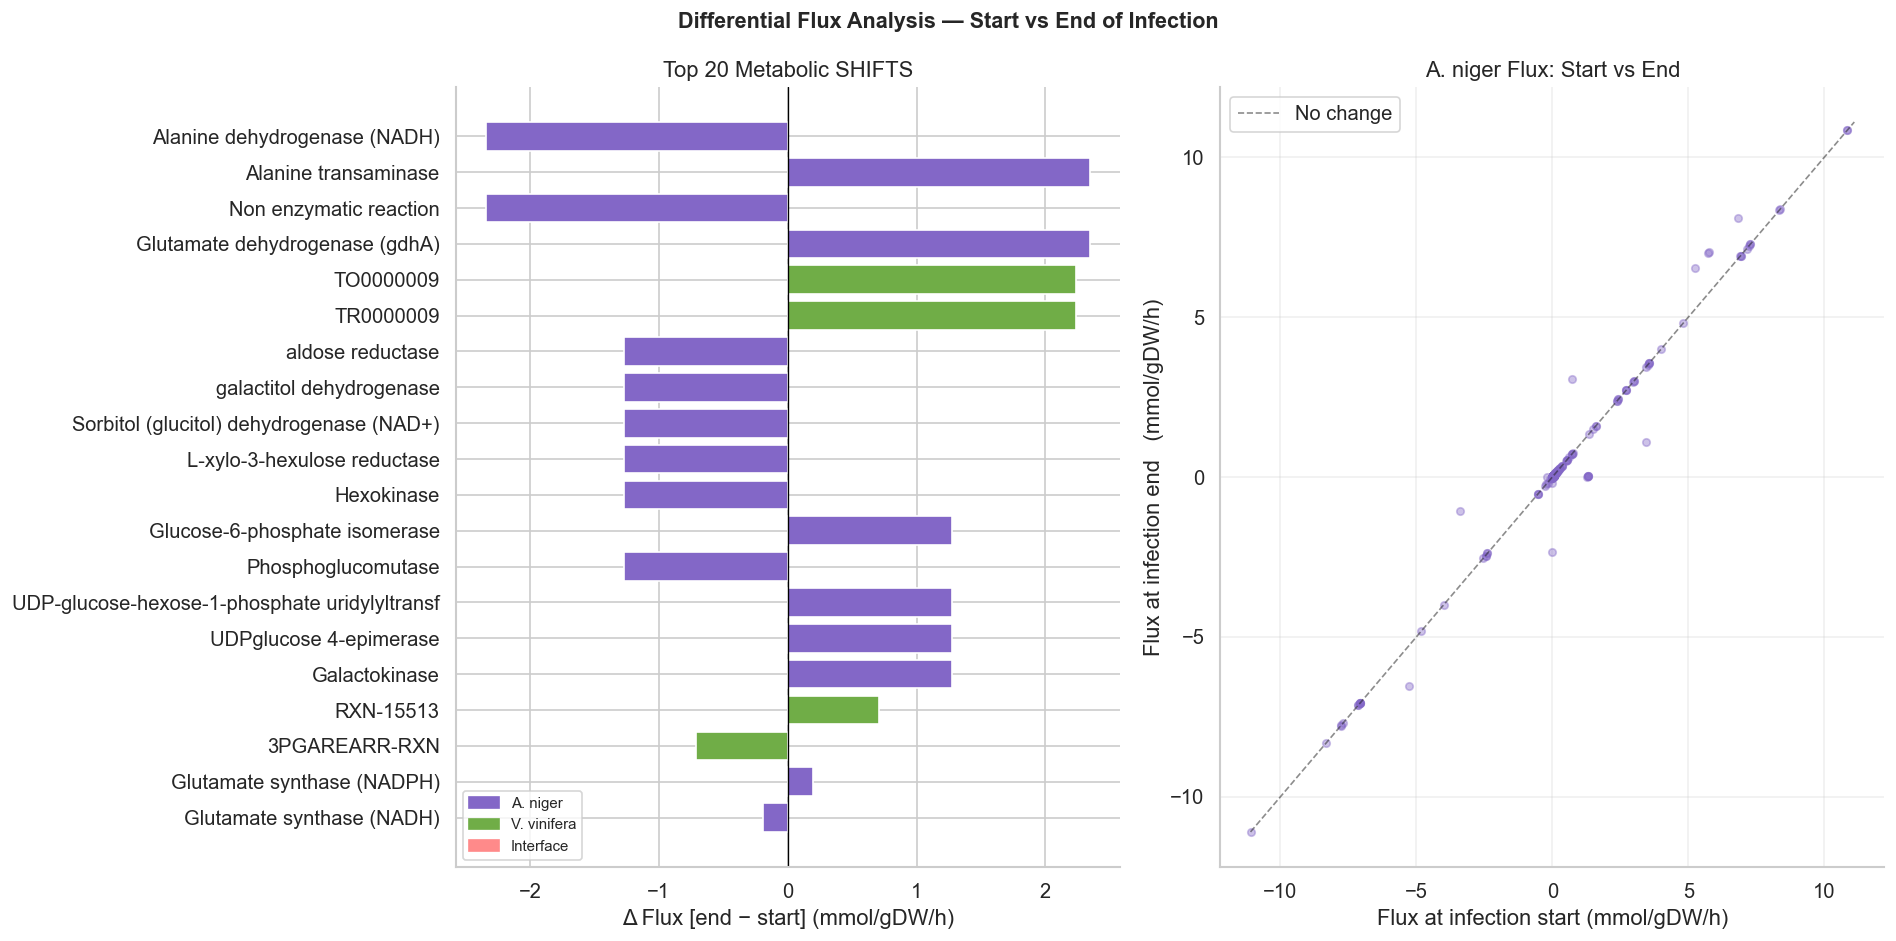


Top 5 upregulated:
                          flux_start  flux_end     delta organism
an_r259                    -3.392117 -1.049843  2.342274       an
an_r290                     0.714381  3.056655  2.342274       an
vv_TO0000009__mito__cyto    0.000000  2.236211  2.236211       vv
vv_TR0000009__mito__cyto   -2.236211  0.000000  2.236211       vv
an_r7                       6.839396  8.111270  1.271874       an

Top 5 downregulated:
          flux_start  flux_end     delta organism
an_r262     3.441263  1.098989 -2.342274       an
an_r908     0.000000 -2.342274 -2.342274       an
an_r172     1.304436  0.032561 -1.271874       an
an_r1274    1.304436  0.032561 -1.271874       an
an_r197     1.304436  0.032561 -1.271874       an


In [23]:
def get_rxn_name(rxn_id):
    try:    return (community.reactions.get_by_id(rxn_id).name or rxn_id)[:45]
    except: return rxn_id[:45]

top20          = df_shifts.head(20).copy()
top20['label'] = top20.index.map(get_rxn_name)
bar_colors     = [C_FUNGUS if r.startswith('an_') else
                  C_GRAPE   if r.startswith('vv_') else C_INF
                  for r in top20.index]

fig, axes = plt.subplots(1, 2, figsize = (16, 8))
fig.suptitle('Differential Flux Analysis — Start vs End of Infection', fontsize = 13, fontweight = 'bold')

axes[0].barh(top20['label'], top20['delta'], color = bar_colors, edgecolor = 'white')
axes[0].axvline(0, color = 'black', lw = 0.8)
axes[0].set_xlabel('Δ Flux [end − start] (mmol/gDW/h)')
axes[0].set_title('Top 20 Metabolic SHIFTS')
axes[0].invert_yaxis()
axes[0].legend(handles = [mpatches.Patch(color = C_FUNGUS, label = 'A. niger'),
                          mpatches.Patch(color = C_GRAPE,  label = 'V. vinifera'),
                          mpatches.Patch(color = C_INF,    label = 'Interface')], fontsize = 9)

an_dfa = df_dfa[(df_dfa['organism'] == 'an') &
                ((df_dfa['flux_start'].abs()>0.01)|(df_dfa['flux_end'].abs()>0.01))]
mv = max(an_dfa['flux_start'].abs().max(), an_dfa['flux_end'].abs().max())
axes[1].scatter(an_dfa['flux_start'], an_dfa['flux_end'], alpha = 0.4, s = 20, color = C_FUNGUS)
axes[1].plot([-mv,mv], [-mv,mv], 'k--', lw = 1, alpha = 0.5, label = 'No change')
axes[1].set_xlabel('Flux at infection start (mmol/gDW/h)')
axes[1].set_ylabel('Flux at infection end   (mmol/gDW/h)')
axes[1].set_title('A. niger Flux: Start vs End')
axes[1].legend(); axes[1].grid(alpha = 0.3)

plt.tight_layout()
# plt.savefig('fig5_differential_flux.png', dpi = 150, bbox_inches = 'tight')
plt.show()

print('\nTop 5 upregulated:')
print(df_shifts[df_shifts['delta']>0].head(5)[['flux_start','flux_end','delta','organism']].to_string())
print('\nTop 5 downregulated:')
print(df_shifts[df_shifts['delta']<0].head(5)[['flux_start','flux_end','delta','organism']].to_string())

In [24]:
for rid in ['an_r14', 'an_r15', 'an_r93', 'an_r94', 'an_r122']:
    rxn = community.reactions.get_by_id(rid)
    print(f'{rid}: {rxn.reaction[:80]}')

an_r14: an_NAD + an_PI + an_T3P1 <=> an_13PDG + an_NADH
an_r15: an_13PDG + an_ADP <=> an_3PG + an_ATP
an_r93: an_METTHF + an_NAD <=> an_METHF + an_NADH
an_r94: an_H2O + an_METHF <=> an_FTHF
an_r122: an_GL + an_NAD <=> an_GLYN + an_NADH


## 11. Transport Knockout Analysis — Essential Interface Metabolites

Each T1 transport reaction is individually knocked out to identify which interface metabolites are essential for *A. niger* growth.
T1 and T2 knockouts are equivalent by design — the series architecture (vv_cytosol → T1 → inf → T2 → an_extracellular) means blocking either transporter produces identical results.

**Essential** = knockout reduces fungal growth to < $1\%$ of baseline ($μ = 0.1809 h⁻¹$).

**Result: only 2/19 interface metabolites are essential — O₂ and Sulfate.**

*A. niger* is a highly versatile saprotroph with extensive biosynthetic capacity, explaining why only 2 metabolites are absolutely required:

- **O₂:** obligate aerobe — cannot grow anaerobically
- **Sulfate:** no internal sulphur source available in *iJB1325* under these conditions
- **Phosphate:** strongest non-essential limiting factor ($Δ = 0.102$, $56\%$ reduction) — fungus partially compensates via internal recycling
- **C-sources (Glucose, Fructose):** substitutable — multiple carbon sources available via T2
- **Organic acids (Malate, Fumarate, Citrate, Succinate):** synthesised internally via TCA — not essential imports
- **Amino acids:** *A. niger* synthesises all standard amino acids from inorganic nitrogen and carbon — none essential

This is biologically consistent with the known ecology of *A. niger* as an opportunistic saprotroph capable of colonising nutrient-poor substrates.

**Essentiality tiers:**

| Tier | Δμ range | Metabolites | Interpretation |
|---|---|---|---|
| Essential | $= 0.1809$ | O₂, Sulfate | Absolute requirement |
| Critical | $0.05–0.18$ | Phosphate ($0.102$) | Strong bottleneck |
| Contributing | $0.001–0.05$ | Glucose ($0.006$), Nitrate ($0.003$), Citrate ($0.0006$), Leucine ($0.0001$) | Minor contribution |
| No impact | $≤ 0.001$ | All others | Substitutable |

In [25]:
def knockout_scan(community, rxn_an, T_reactions, T1_reactions, T2_reactions, baseline, label):
    """
    Knockout each transport reaction individually.
    All other T1/T2 are opened to 10.0 before each KO to ensure the baseline is recoverable and results are comparable.
    """
    results = []
    for r_id in T_reactions:
        met_name = r_id.replace('T1_','').replace('T2_','')
        with community:
            # Open all T1/T2 to 10.0, then block the target
            for t_id in T1_reactions + T2_reactions:
                try: community.reactions.get_by_id(t_id).upper_bound = 10.0
                except KeyError: pass
            try:
                r = community.reactions.get_by_id(r_id)
                r.upper_bound = 0; r.lower_bound = 0
            except KeyError:
                continue
            community.objective = {rxn_an: 1}
            sol = community.optimize()
            g   = sol.objective_value if sol.status == 'optimal' else 0
            imp = baseline - g
            ess = g < 0.01 * baseline
            results.append({'reaction'  : r_id,
                            'metabolite': met_name,
                            'category'  : INTERFACE_EXACT.get(met_name, {}).get('cat', '?'),
                            'growth_KO' : round(g, 4),
                            'impact'    : round(imp, 4),
                            'rel_impact': round(imp / baseline * 100, 1) if baseline > 0 else 0,
                            'essential' : ess,})
            flag = '  * ESSENTIAL' if ess else ''
            print(f'    KO {met_name:<14}: μ = {g:.4f}  Δ = {imp:.4f}{flag}')
    return pd.DataFrame(results).sort_values('impact', ascending = False)

with community:
    for t_id in T1_reactions + T2_reactions:
        try: community.reactions.get_by_id(t_id).upper_bound = 10.0
        except KeyError: pass
    community.objective = {rxn_an: 1}
    baseline_ko = community.optimize().objective_value
    print(f'Baseline (all T1/T2 open): {baseline_ko:.4f} h⁻¹\n')

print('T1 Knockout')
df_t1_ko = knockout_scan(community, rxn_an, T1_reactions, T1_reactions, T2_reactions, baseline_ko, 'T1')
print('\nT2 Knockout')
df_t2_ko = knockout_scan(community, rxn_an, T2_reactions, T1_reactions, T2_reactions, baseline_ko, 'T2')

Baseline (all T1/T2 open): 0.1809 h⁻¹

T1 Knockout
    KO Glucose       : μ = 0.1751  Δ = 0.0058
    KO Fructose      : μ = 0.1809  Δ = 0.0000
    KO Malate        : μ = 0.1809  Δ = -0.0000
    KO Fumarate      : μ = 0.1809  Δ = -0.0000
    KO Citrate       : μ = 0.1803  Δ = 0.0006
    KO Succinate     : μ = 0.1809  Δ = -0.0000
    KO Proline       : μ = 0.1809  Δ = -0.0000
    KO Leucine       : μ = 0.1808  Δ = 0.0001
    KO Serine        : μ = 0.1809  Δ = -0.0000
    KO Glutamate     : μ = 0.1809  Δ = -0.0000
    KO Alanine       : μ = 0.1809  Δ = -0.0000
    KO Glycine       : μ = 0.1809  Δ = -0.0000
    KO Nitrate       : μ = 0.1778  Δ = 0.0031
    KO Phosphate     : μ = 0.0788  Δ = 0.1021
    KO Sulfate       : μ = 0.0000  Δ = 0.1809  * ESSENTIAL
    KO Adenine       : μ = 0.1809  Δ = -0.0000
    KO O2            : μ = 0.0000  Δ = 0.1809  * ESSENTIAL
    KO CO2           : μ = 0.1809  Δ = -0.0000
    KO Water         : μ = 0.1809  Δ = -0.0000

T2 Knockout
    KO Glucose       : μ 

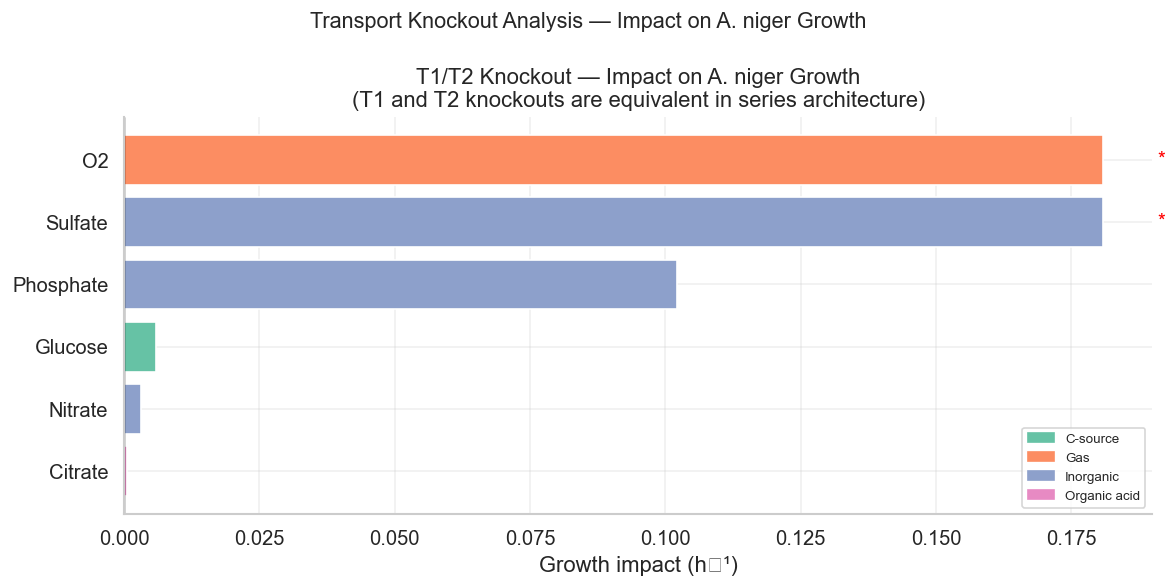

In [26]:
df_t1_plot = df_t1_ko[df_t1_ko['impact'].abs() > 0.0001]
df_t2_plot = df_t2_ko[df_t2_ko['impact'].abs() > 0.0001]
cats_plot  = sorted(set(df_t1_plot['category'].tolist()) | set(df_t2_plot['category'].tolist()))
cat_colors = dict(zip(cats_plot, sns.color_palette('Set2', len(cats_plot))))

fig, ax = plt.subplots(figsize = (10, max(4, len(df_t1_plot)*0.5+2)))
fig.suptitle('Transport Knockout Analysis — Impact on A. niger Growth', fontsize = 13)

bar_c = [cat_colors.get(c,'grey') for c in df_t1_plot['category']]
bars  = ax.barh(df_t1_plot['metabolite'], 
                df_t1_plot['impact'],
                color     = bar_c, 
                edgecolor = 'white')
for bar, ess in zip(bars, df_t1_plot['essential']):
    if ess:
        ax.text(bar.get_width()+0.01, 
                bar.get_y()+bar.get_height()/2,
                '*', 
                va       = 'center', 
                fontsize = 12, 
                color    = 'red')
ax.set_xlabel('Growth impact (h⁻¹)')
ax.set_title('T1/T2 Knockout — Impact on A. niger Growth\n(T1 and T2 knockouts are equivalent in series architecture)')
ax.axvline(0, color = 'black', lw = 0.8)
ax.invert_yaxis()
ax.grid(alpha = 0.3)
ax.legend(handles = [mpatches.Patch(color = c, label = k) for k,c in cat_colors.items()], fontsize = 8)
plt.tight_layout()
# plt.savefig('fig6_transport_knockout.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## 12. FVA — Maximum Flux per Transport Reaction

FVA at `fraction_of_optimum = 0.9` reveals which transport reactions are flexible (high range) vs. rigid bottlenecks (near-zero range).

**Note on Fructose:** `T1_Fructose` and `T2_Fructose` show `range = 0` (FVA confirmed). *iJB1325* lacks an efficient fructose uptake pathway — the two "fructokinase" reactions identified (`r10`, `r193`) operate on fructose-6-phosphate (F6P), not free fructose, and Hexokinase (`r186a`) carries zero flux at the FBA optimum. Extracellular fructose cannot enter glycolysis at significant flux. Fructose is retained in the interface for biological completeness but contributes zero to fungal growth in this model.

FVA — Transport reactions (fraction_of_optimum = 0.9):
               minimum    maximum      range type        met
T1_Glucose    0.000000   1.909091   1.909091   T1    Glucose
T1_Fructose   0.000000   0.000000   0.000000   T1   Fructose
T1_Malate     0.000000   2.560614   2.560614   T1     Malate
T1_Fumarate   0.000000   2.560614   2.560614   T1   Fumarate
T1_Citrate    0.000000   1.711421   1.711421   T1    Citrate
T1_Succinate  0.000000   1.322484   1.322484   T1  Succinate
T1_Proline    0.000000   0.967514   0.967514   T1    Proline
T1_Leucine    0.000000   0.865562   0.865562   T1    Leucine
T1_Serine     0.000000   1.162344   1.162344   T1     Serine
T1_Glutamate  0.000000   1.051106   1.051106   T1  Glutamate
T1_Alanine    0.000000   1.140049   1.140049   T1    Alanine
T1_Glycine    0.000000   1.177250   1.177250   T1    Glycine
T1_Nitrate    0.000000  10.000000  10.000000   T1    Nitrate
T1_Phosphate  0.018212  10.000000   9.981788   T1  Phosphate
T1_Sulfate    0.007879  10.000

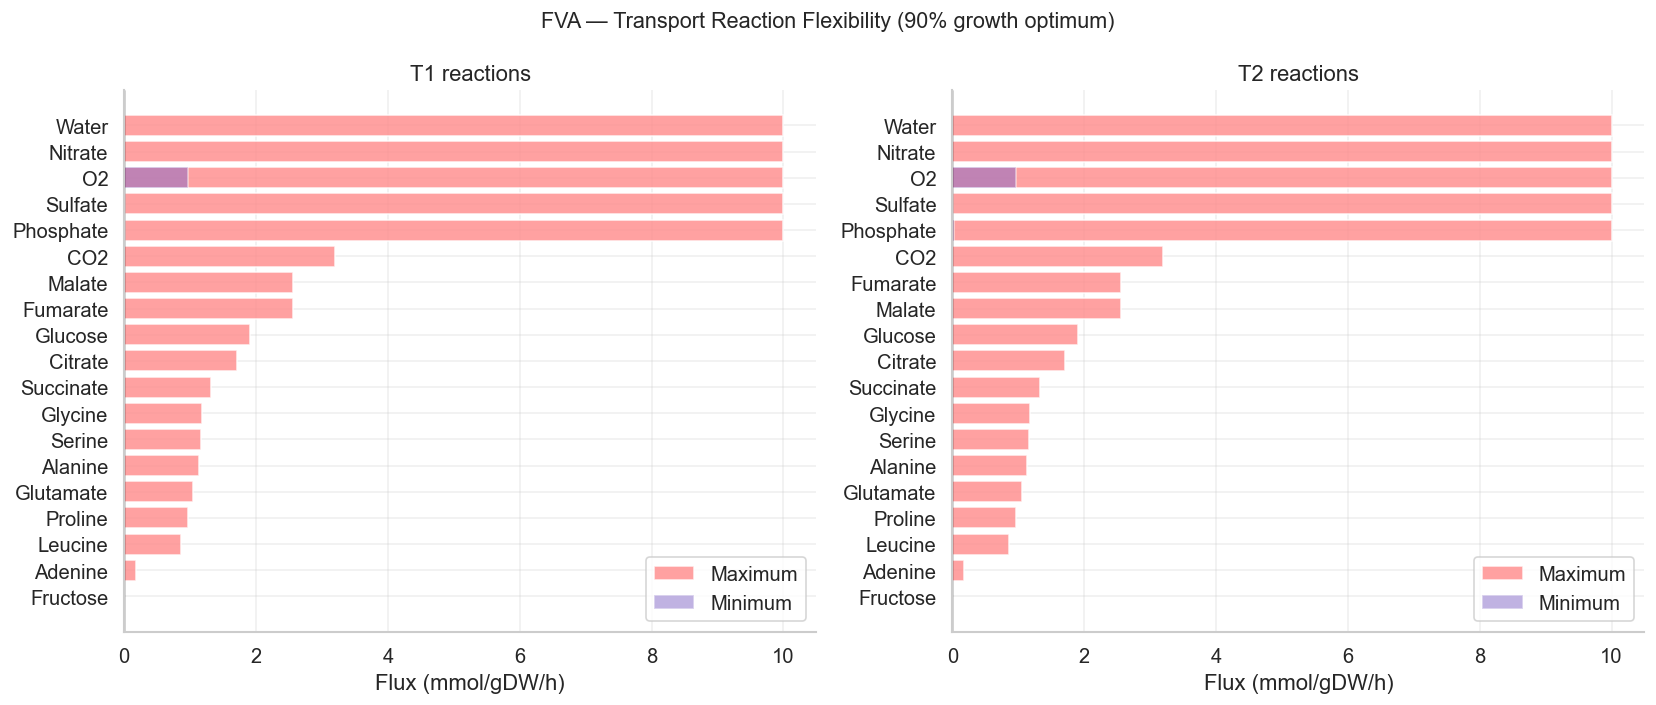

In [27]:
with community:
    for t_id in T1_reactions + T2_reactions:
        try: community.reactions.get_by_id(t_id).upper_bound = 10.0
        except KeyError: pass
    community.objective = {rxn_an: 1}
    transport_ids = [r for r in T1_reactions + T2_reactions
                     if r in {x.id for x in community.reactions}]
    fva_transport = flux_variability_analysis(community, reaction_list = transport_ids, fraction_of_optimum = 0.9, processes = 1)

fva_transport['range'] = fva_transport['maximum'] - fva_transport['minimum']
fva_transport['type']  = fva_transport.index.map(lambda r: 'T1' if r.startswith('T1_') else 'T2')
fva_transport['met']   = fva_transport.index.map(lambda r: r.replace('T1_','').replace('T2_',''))

print('FVA — Transport reactions (fraction_of_optimum = 0.9):')
print(fva_transport[['minimum','maximum','range','type','met']].to_string())

fig, axes = plt.subplots(1, 2, figsize = (14, 6))
fig.suptitle('FVA — Transport Reaction Flexibility (90% growth optimum)', fontsize = 13)
for ax, rtype in zip(axes, ['T1','T2']):
    sub = fva_transport[fva_transport['type'] == rtype].sort_values('maximum', ascending = False)
    ax.barh(sub['met'], sub['maximum'], color = C_INF,    alpha = 0.8, label = 'Maximum')
    ax.barh(sub['met'], sub['minimum'], color = C_FUNGUS, alpha = 0.5, label = 'Minimum')
    ax.axvline(0, color = 'black', lw = 0.8)
    ax.set_xlabel('Flux (mmol/gDW/h)'); ax.set_title(f'{rtype} reactions')
    ax.legend(); ax.invert_yaxis(); ax.grid(alpha = 0.3)
plt.tight_layout()
# plt.savefig('fig7_fva_transport.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## 13. Scenario Comparison — Free vs Stressed

Two vine supply scenarios modelled via `vv_BOUNDARY_*` reactions. The `cyto_flux_proxy` is recomputed from the grape pFBA under each scenario — T1 leakage reflects the grape's actual metabolic state:

- **Free (vine-attached):** boundary reactions at default model bounds — grape operates at full metabolic capacity.
- **Stressed (drought/heat):** all boundary uptakes scaled by $50\%$ — reduced phloem/xylem supply, lower cytoplasmic metabolic activity.

**Results:**
* **Free:** *A. niger* reaches $K = 50 gDW/L$ at $t ≈ 88h$ — rapid infection.
* **Stressed (50%):** peak biomass reduced to $8.16 gDW/L$ at $t ≈ 119h$ — $84\%$ reduction in fungal load and ~$30h$ delay in infection progression.

Drought/heat stress, by reducing cytoplasmic metabolite availability, significantly impairs fungal colonisation — even though it does not eliminate infection.

Running: Free (vine-attached)...
  Peak A. niger: 50.00 gDW/L at t = 88h
Running: Stressed (50%)...
  Peak A. niger: 8.16 gDW/L at t = 119h


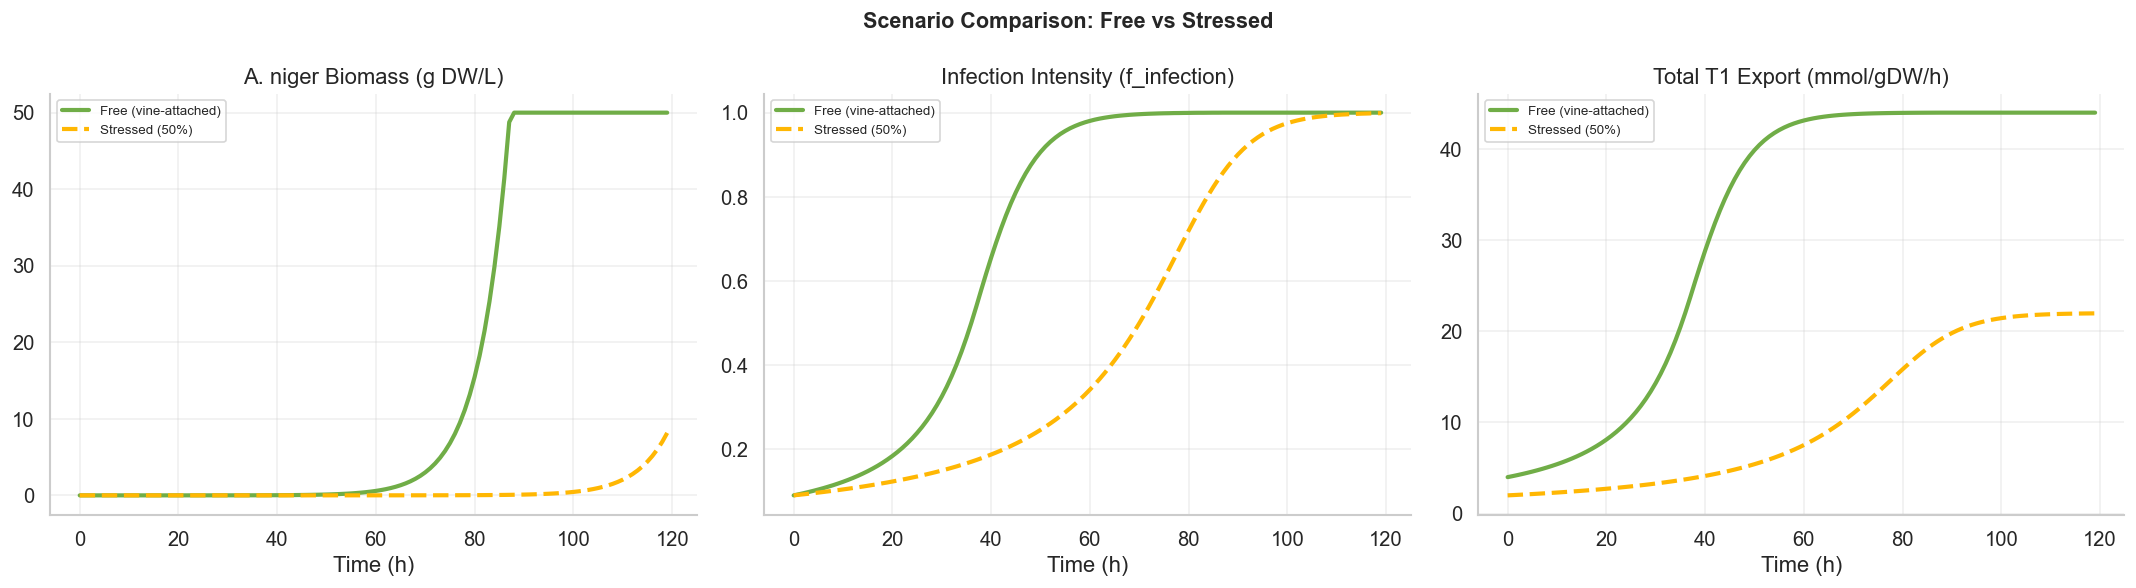

In [28]:
# Compute proxies for each scenario
proxy_free     = compute_proxy(community, vv_biomass_id)
proxy_stressed = {k: v * 0.5 for k, v in proxy_free.items()}

scenario_proxies = {'Free (vine-attached)': proxy_free,
                    'Stressed (50%)'      : proxy_stressed,}

colors_sc = {'Free (vine-attached)': C_GRAPE, 'Stressed (50%)': C_SHIFT}
ls_sc     = {'Free (vine-attached)': '-',     'Stressed (50%)': '--'}

df_scenarios = {}
for name, proxy in scenario_proxies.items():
    print(f'Running: {name}...')
    df_s = run_dfba(community,
                    vv_biomass_id,
                    an_growth_id,
                    T1_reactions,
                    T2_reactions,
                    INTERFACE_MAP,
                    cyto_flux_proxy = proxy,
                    dt    = 1.0,
                    t_end = 120.0,
                    label = f'[{name[:4]}]')
    df_scenarios[name] = df_s
    peak = df_s['biomass_an'].max()
    tpk  = df_s.loc[df_s['biomass_an'].idxmax(), 'time_h']
    print(f'  Peak A. niger: {peak:.2f} gDW/L at t = {tpk:.0f}h')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Scenario Comparison: Free vs Stressed', fontsize=13, fontweight='bold')

for name, df_s in df_scenarios.items():
    kw = dict(color=colors_sc[name], ls=ls_sc[name], lw=2.5, label=name)
    axes[0].plot(df_s['time_h'], df_s['biomass_an'],  **kw)
    axes[1].plot(df_s['time_h'], df_s['f_infection'], **kw)
    axes[2].plot(df_s['time_h'], df_s['T1_total'],    **kw)

labels = ['A. niger Biomass (g DW/L)',
          'Infection Intensity (f_infection)',
          'Total T1 Export (mmol/gDW/h)']
for ax, lbl in zip(axes, labels):
    ax.set_title(lbl); ax.set_xlabel('Time (h)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('fig8_scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Minimal Medium Analysis — Absolute Fungal Requirements

Identifies the smallest set of nutrients that allows *A. niger* to grow at a minimum viable rate. Uses COBRApy's `minimal_medium()` on the isolated fungus
model to confirm the absolute nutritional floor before co-culture analysis. This complements the T1/T2 knockout analysis.

In [29]:
with an_raw:
    min_med = minimal_medium(an_raw, minimize_components = True)
print(f'Minimal medium for A. niger (μ ≥ 0.1 h⁻¹):')
print(f'    Components required: {len(min_med)}')
for rxn_id, bound in sorted(min_med.items()):
    try:
        rxn = an_raw.reactions.get_by_id(rxn_id)
        met_name = list(rxn.metabolites.keys())[0].name if rxn.metabolites else rxn_id
    except:
        met_name = rxn_id
    print(f'    {rxn_id:<20} {met_name:<35} (ub = {bound:.1f})')

Minimal medium for A. niger (μ ≥ 0.1 h⁻¹):
    Components required: 4
    BOUNDARY_GLCe        alpha-D-Glucose (extracellular)     (ub = 10.0)
    BOUNDARY_HNO3e       Nitrate (extracellular)             (ub = 1.8)
    BOUNDARY_O2e         Oxygen (extracellular)              (ub = 49.4)
    BOUNDARY_SLFe        Sulfate (extracellular)             (ub = 0.0)


## 15. Target Selectivity — Fungal-Exclusive Essential Genes

Identifies essential *A. niger* genes with **no orthologue in *V. vinifera***, providing candidate targets for disease management that would not harm the host.

Gene IDs are compared between organisms. Genes are considered exclusive to the fungus if no matching base ID exists in the grape model.

**Limitation:** Gene IDs in *iJB1325* use NCBI numeric format (e.g. 1012621) while *iMS7199* uses BioCyc/internal IDs — the comparison is by string matching
only. The 100% selectivity ratio reflects nomenclature incompatibility, not confirmed absence of orthologues.

In [30]:
ess_genes_an = find_essential_genes(an_raw, processes = 1)
ess_ids_an   = {g.id for g in ess_genes_an}
print(f'Essential A. niger genes: {len(ess_ids_an)}')

host_gene_bases = {g.id.lower() for g in vv_raw.genes}

exclusive_targets = []
shared_targets    = []

for gene_id in ess_ids_an:
    base = gene_id.lower()
    if any(base in h for h in host_gene_bases) or any(h in base for h in host_gene_bases if len(h) > 5):
        shared_targets.append(gene_id)
    else:
        exclusive_targets.append(gene_id)

print(f'\nTarget Selectivity Summary')
print(f'{"_"*45}')
print(f'    Total essential A. niger genes      : {len(ess_ids_an)}')
print(f'    Potentially shared with V. vinifera : {len(shared_targets)}')
print(f'    Exclusive to A. niger (safe targets): {len(exclusive_targets)}')
print(f'    Selectivity ratio                   : {len(exclusive_targets)/len(ess_ids_an)*100:.1f}%')

print(f'\nSample exclusive essential genes (top 20):')
for gene_id in sorted(exclusive_targets)[:20]:
    try:
        gene = an_raw.genes.get_by_id(gene_id)
        rxn_ids = [r.id for r in gene.reactions][:2]
        print(f'  {gene_id:<20} → reactions: {rxn_ids}')
    except:
        print(f'  {gene_id}')

Essential A. niger genes: 140

Target Selectivity Summary
_____________________________________________
    Total essential A. niger genes      : 140
    Potentially shared with V. vinifera : 0
    Exclusive to A. niger (safe targets): 140
    Selectivity ratio                   : 100.0%

Sample exclusive essential genes (top 20):
  1012621              → reactions: ['r279', 'r277']
  1027809              → reactions: ['r479']
  1030265              → reactions: ['r281']
  1039502              → reactions: ['r375']
  1080533              → reactions: ['r1229', 'r1257']
  1081081              → reactions: ['r495']
  1081703              → reactions: ['r324']
  1086696              → reactions: ['r424']
  1086744              → reactions: ['r856', 'r857']
  1089890              → reactions: ['RNApolym']
  1094131              → reactions: ['r865']
  1095920              → reactions: ['r548']
  1097533              → reactions: ['r212']
  1099044              → reactions: ['r365']
  10995

## 16. Model Limitations

**Limitations specific to the community model and dFBA framework:**

1. **Sequential FBA approximation:** Grape and fungus are optimised independently at each timestep — not as a true joint community optimisation. Metabolic coupling is approximated via T1/T2 bounds.

2. **Leakage model assumptions:** T1 bounds are proportional to the grape cytoplasmic flux proxy (pFBA-derived). This assumes passive metabolite leakage proportional to metabolic activity. Active secretion, defence-induced export, or cell wall barrier dynamics are not captured.

3. **Constant grape biomass:** `bm_vv` is held constant throughout the simulation (post-mitotic tissue approximation). Tissue degradation by fungal hydrolases is not modelled — in reality, berry integrity decreases as infection progresses.

4. **Well-mixed interface:** The infection compartment is a homogeneous abstraction — no spatial gradients, diffusion barriers, or hyphal penetration dynamics.

5. **Static pFBA proxy:** The cytoplasmic flux proxy is computed once from grape pFBA at full capacity and held constant throughout the simulation. In reality, grape metabolism changes as infection progresses and host suppression increases.

6. **Individual model limitations** are documented in Phase 1A (*A. niger*, `An_curated.xml`) and Phase 1B (*V. vinifera*, `VvM_mature_curated.xml`).

## 17. References

* **iJB1325** (Brandl et al., 2018)

Brandl, J., Aguilar-Pontes, M. V., Schäpe, P., Nørregaard, A., Arvas, M., Ram, A. F. J., Meyer, V., Tsang, A., de Vries, R. P., & Andersen, M. R. (2018). A community-driven reconstruction of the *Aspergillus niger* metabolic network. *Fungal Biology and Biotechnology*, *5*, 16. https://doi.org/10.1186/s40694-018-0060-7

* **iMS7199** (Sampaio, M., Rocha, M., & Dias, O., 2024)

Sampaio, M., Rocha, M., & Dias, O. (2024). iMS7199 – genome-scale metabolic model of *Vitis vinifera* (Model ID MODEL2408120001). [Data set]. BioModels. https://biomodels.org/MODEL2408120001

## Metabolic Interface Visualisation

Custom pathway map showing the host–pathogen metabolic interface at peak infection (mature berry, $f_{\\text{infection}} = 0.95$, $t = 54\\,h$). Each node in the T1 compartment represents a metabolite transferred from the *V. vinifera* cytosol to *A. niger* via T1 transport reactions. Node size and arrow thickness are proportional to the T1 proxy flux; blocked metabolites (zero flux) are shown in grey.


In [ ]:
# ── Metabolic Interface Map — V. vinifera × A. niger ──────────────────────
# Custom pathway visualisation of the T1 transport interface.
# Node size and arrow thickness ∝ T1 proxy flux (mature berry, dFBA).
# Proxy values from compute_proxy() — see 3B_green_mature_comparison.ipynb.
# Saved as: metabolic_interface_map.png
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.colors import Normalize

PROXY = {
    'Citrate':19.37,'Phosphate':13.34,'Glycine':2.59,'Alanine':1.95,
    'Glutamate':1.54,'Nitrate':1.46,'Serine':1.28,'Malate':0.19,
    'Leucine':0.10,'Glucose':0.0,'Fructose':0.0,'Fumarate':0.0,
    'Succinate':0.0,'Adenine':0.0,'Sulfate':0.0,
}
CAT = {
    'C-source':'#CA6F1E','Organic acid':'#7D3C98',
    'Amino acid':'#1E8449','Inorganic':'#1A5276',
}
MET_CAT = {
    'Citrate':'Organic acid','Malate':'Organic acid','Fumarate':'Organic acid',
    'Succinate':'Organic acid','Phosphate':'Inorganic','Nitrate':'Inorganic',
    'Sulfate':'Inorganic','Glutamate':'Amino acid','Alanine':'Amino acid',
    'Glycine':'Amino acid','Serine':'Amino acid','Leucine':'Amino acid',
    'Glucose':'C-source','Fructose':'C-source','Adenine':'C-source',
}

fig, ax = plt.subplots(figsize=(22,12))
ax.set_xlim(0,22); ax.set_ylim(0,12)
ax.axis('off')
fig.patch.set_facecolor('#F4F6F7'); ax.set_facecolor('#F4F6F7')

# Panels
for x0,y0,w,h,col,lbl in [
    (0.2,0.5,5.6,11.0,'#D6EAF8','V. vinifera\n(Host Cytosol)'),
    (6.1,0.5,9.8,11.0,'#FDFEFE','T1 Transport Interface\n(Infection Compartment)'),
    (16.2,0.5,5.6,11.0,'#FEF9E7','A. niger\n(Pathogen)'),
]:
    ax.add_patch(mpatches.FancyBboxPatch((x0,y0),w,h,
        boxstyle='round,pad=0.2',fc=col,ec='#AAB7B8',lw=1.5,zorder=0,alpha=0.65))
    ax.text(x0+w/2,y0+h+0.15,lbl,ha='center',va='bottom',
            fontsize=11,fontweight='bold',color='#1C2833')

cmap = plt.cm.get_cmap('YlOrRd')
max_p = max(v for v in PROXY.values() if v>0)
norm  = Normalize(0,max_p)

def node(x,y,r,fc,ec='white',lw=1.5,alpha=0.93,zorder=3):
    c = plt.Circle((x,y),r,color=fc,zorder=zorder,alpha=alpha,lw=lw,ec=ec)
    ax.add_patch(c); return c

def label(x,y,txt,fs=7,fw='bold',col='white',zorder=4):
    ax.text(x,y,txt,ha='center',va='center',fontsize=fs,
            fontweight=fw,color=col,zorder=zorder)

def arrow(x1,y1,x2,y2,lw=1.5,col='#95A5A6',rad=0.0,ms=10,alpha=1.0):
    ax.annotate('',xy=(x2,y2),xytext=(x1,y1),
        arrowprops=dict(arrowstyle='->',color=col,lw=lw,
            mutation_scale=ms,connectionstyle=f'arc3,rad={rad}',alpha=alpha))

# ── HOST ──────────────────────────────────────────────────────────────────────
H = {
    'Sucrose\nreserve':(3.0,10.8),'Glucose':(1.8,9.3),'Fructose':(4.2,9.3),
    'Citrate\n(TCA)':(3.0,7.8),'Malate\n(TCA)':(3.0,6.4),'Phosphate':(3.0,5.0),
    'Glutamate':(1.5,3.6),'Glycine':(3.0,3.6),'Alanine':(4.5,3.6),
    'Serine':(1.5,2.2),'Leucine':(4.5,2.2),'Nitrate':(3.0,1.0),
}
HC = {'Sucrose\nreserve':'#F0B27A','Glucose':CAT['C-source'],'Fructose':CAT['C-source'],
      'Citrate\n(TCA)':CAT['Organic acid'],'Malate\n(TCA)':CAT['Organic acid'],
      'Phosphate':CAT['Inorganic'],'Glutamate':CAT['Amino acid'],'Glycine':CAT['Amino acid'],
      'Alanine':CAT['Amino acid'],'Serine':CAT['Amino acid'],'Leucine':CAT['Amino acid'],
      'Nitrate':CAT['Inorganic']}

for n,(x,y) in H.items():
    node(x,y,0.48,HC[n]); label(x,y,n)

for s,d in [('Sucrose\nreserve','Glucose'),('Sucrose\nreserve','Fructose'),
            ('Citrate\n(TCA)','Malate\n(TCA)')]:
    x1,y1=H[s]; x2,y2=H[d]
    arrow(x1,y1,x2,y2,col='#95A5A6',lw=1.2,ms=9)

# ── INTERFACE ─────────────────────────────────────────────────────────────────
T1 = {
    'Citrate':(11.0,10.8),'Phosphate':(11.0,9.3),
    'Glycine':(8.0,7.9),'Alanine':(11.0,7.9),'Glutamate':(14.0,7.9),
    'Nitrate':(8.0,6.5),'Serine':(11.0,6.5),'Malate':(14.0,6.5),
    'Leucine':(8.0,5.1),'Glucose':(11.0,5.1),'Fructose':(14.0,5.1),
    'Fumarate':(8.0,3.7),'Succinate':(11.0,3.7),'Adenine':(14.0,3.7),
    'Sulfate':(11.0,2.3),
}
for met,(x,y) in T1.items():
    flux = PROXY.get(met,0)
    r    = 0.32+(flux/max_p)*0.50 if flux>0 else 0.28
    fc   = cmap(norm(flux)) if flux>0 else '#E5E7E9'
    ec   = CAT.get(MET_CAT.get(met,'C-source'),'#BDC3C7')
    node(x,y,r,fc,ec=ec,lw=2.0 if flux>0 else 0.7)
    ax.text(x,y+0.07,met,ha='center',va='center',fontsize=6.5,
            fontweight='bold',color='#1C2833',zorder=4)
    if flux>0:
        ax.text(x,y-0.28,f'{flux:.1f}',ha='center',va='center',
                fontsize=5.5,color='#641E16',fontweight='bold',zorder=4)
    else:
        ax.text(x,y-0.22,'blocked',ha='center',va='center',
                fontsize=5,color='#AAB7B8',style='italic',zorder=4)

# ── T1 arrows host→interface (draw BEHIND nodes with zorder=2) ────────────────
T1L = {
    'Citrate':('Citrate\n(TCA)','Citrate'),'Phosphate':('Phosphate','Phosphate'),
    'Glycine':('Glycine','Glycine'),'Alanine':('Alanine','Alanine'),
    'Glutamate':('Glutamate','Glutamate'),'Nitrate':('Nitrate','Nitrate'),
    'Serine':('Serine','Serine'),'Malate':('Malate\n(TCA)','Malate'),
    'Leucine':('Leucine','Leucine'),'Glucose':('Glucose','Glucose'),
    'Fructose':('Fructose','Fructose'),
}
for met,(hn,tn) in T1L.items():
    flux = PROXY.get(met,0)
    x1,y1 = H[hn]; x2,y2 = T1[tn]
    lw  = max(0.4,(flux/max_p)*7)
    col = cmap(norm(flux)) if flux>0 else '#D5D8DC'
    alp = 0.88 if flux>0 else 0.25
    # offset start by node radius
    ax.annotate('',xy=(x2,y2),xytext=(x1+0.48,y1),
        arrowprops=dict(arrowstyle='->',color=col,lw=lw,
            mutation_scale=7+lw*1.5,alpha=alp,zorder=2))

# ── FUNGAL ────────────────────────────────────────────────────────────────────
AN = {
    'Citrate\nuptake':(19.0,10.8),'PO₄\nuptake':(19.0,9.3),
    'AA pool':(19.0,7.9),'Glycolysis':(19.0,6.4),
    'TCA cycle':(19.0,4.9),'Citrate\nsecretion':(19.0,3.4),
    'Biomass\nμ=0.154':(19.0,1.9),
}
ANC = {'Citrate\nuptake':CAT['Organic acid'],'PO₄\nuptake':CAT['Inorganic'],
       'AA pool':CAT['Amino acid'],'Glycolysis':'#C0392B','TCA cycle':'#7D3C98',
       'Citrate\nsecretion':'#D35400','Biomass\nμ=0.154':'#1E8449'}

for n,(x,y) in AN.items():
    node(x,y,0.55,ANC[n],lw=1.8); label(x,y,n)

for s,d in [('Citrate\nuptake','TCA cycle'),('PO₄\nuptake','Biomass\nμ=0.154'),
            ('AA pool','Biomass\nμ=0.154'),('Glycolysis','TCA cycle'),
            ('TCA cycle','Citrate\nsecretion'),('TCA cycle','Biomass\nμ=0.154')]:
    x1,y1=AN[s]; x2,y2=AN[d]
    arrow(x1,y1-0.55,x2,y2+0.55,col='#7B241C',lw=2.0,ms=12)

# ── T2 arrows interface→fungus ────────────────────────────────────────────────
T2M = {'Citrate':'Citrate\nuptake','Phosphate':'PO₄\nuptake',
       'Glycine':'AA pool','Alanine':'AA pool','Glutamate':'AA pool',
       'Nitrate':'PO₄\nuptake','Serine':'AA pool','Leucine':'AA pool',
       'Glucose':'Glycolysis','Fructose':'Glycolysis'}
_d = {}
for met,an_node in T2M.items():
    flux = PROXY.get(met,0)
    if flux==0: continue
    x1,y1=T1[met]; x2,y2=AN[an_node]
    lw  = max(0.4,(flux/max_p)*7)
    col = cmap(norm(flux))
    n   = _d.get(an_node,0)
    rad = [0.0,0.13,-0.13,0.24,-0.24][min(n,4)]
    _d[an_node]=n+1
    arrow(x1+0.28,y1,x2-0.55,y2,col=col,lw=lw,rad=rad,ms=7+lw*1.5)

# ── Decorations ───────────────────────────────────────────────────────────────
ax.text(11.0,12.0,'T1 Transport  (Host Cytosol → Infection Compartment → Fungus)',
        ha='center',va='center',fontsize=9.5,fontweight='bold',color='#1A5276',
        bbox=dict(boxstyle='round,pad=0.3',fc='#D6EAF8',ec='#1A5276',alpha=0.9))
ax.text(11.0,0.85,
        'Mature berry  ·  f_infection = 0.95 at t = 54h  ·  '
        'Total T1 proxy = 42.1 mmol/gDW/h  ·  Dominant: Citrate (46%)',
        ha='center',fontsize=8,color='#1A5276',
        bbox=dict(boxstyle='round,pad=0.3',fc='#EAF2FF',ec='#1A5276',alpha=0.85))

# legend
ax.legend(handles=[
    mpatches.Patch(fc=CAT['Organic acid'],label='Organic acid'),
    mpatches.Patch(fc=CAT['Inorganic'],   label='Inorganic'),
    mpatches.Patch(fc=CAT['Amino acid'],  label='Amino acid'),
    mpatches.Patch(fc=CAT['C-source'],    label='Carbon source'),
    mpatches.Patch(fc='#E5E7E9',ec='#AAB7B8',label='Blocked / zero flux'),
],loc='lower left',fontsize=8,framealpha=0.9,
  title='Metabolite category',title_fontsize=8,bbox_to_anchor=(0.01,0.09))

sm=plt.cm.ScalarMappable(cmap='YlOrRd',norm=norm); sm.set_array([])
plt.colorbar(sm,ax=ax,shrink=0.28,aspect=10,location='bottom',
             pad=0.02,anchor=(0.5,0.0)).set_label('T1 proxy flux (mmol/gDW/h)',fontsize=9)

ax.set_title(
    'Metabolic Interface Map — V. vinifera × A. niger Infection (Mature Berry, dFBA)\n'
    'Node size and arrow thickness ∝ T1 flux proxy  ·  Node border colour = metabolite category',
    fontsize=12,fontweight='bold',pad=10,color='#1C2833')

plt.tight_layout()
plt.savefig('metabolic_interface_map.png', dpi=200,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

